#### Parag Chettri ~ Santiago Berumen
# An Analysis of the Milky Way's Rotation Curve: A Julia Approach
## Training on Gaia DR3, Testing on an Independent Gaia DR2 Sample

> **How to run this notebook.** Run all cells from the top (*Kernel → Restart Kernel and Run All Cells*) on a computer with internet access. The first run sends two queries to the ESA Gaia Archive and usually takes somewhere between 5 and 30 minutes, depending on how busy the archive is; the cell prints each job's progress while you wait. The results are cached in `DataSets/` next to this notebook, so every later run takes seconds. You need Python 3.9+ with `numpy pandas scipy matplotlib requests` (plus `ipywidgets` for the sliders and `astropy` for an optional cross-check); the first code cell can install them. When it finishes, save the notebook *with its outputs* — the last cell also writes `results_summary.json`, which collects every key number from the run in one place.

For anyone who has looked up at the Milky Way from somewhere truly dark it is easy to think of our galaxy as a still band of light. In reality, it is a spinning disk, and the speed at which its stars orbit tells us how much mass is holding them in place. The *rotation curve*, which is the orbital speed plotted against distance from the Galactic Center, is one of the oldest and most important pieces of evidence that the galaxy contains far more mass than we can see.

This notebook uses astrometry (positions, parallaxes and proper motions) and spectroscopic radial velocities from the European Space Agency's *Gaia* mission to measure that curve ourselves. We train a set of increasingly physical models on **Gaia Data Release 3** (Gaia Collaboration, Vallenari et al. 2023) and then check whether those models hold up on an **independent sample of different stars from Gaia Data Release 2** (Gaia Collaboration, Brown et al. 2018). The project began as a computational astrophysics class project on galactic dynamics, and this version is a substantially reworked edition of it.

# Setup

Everything you might want to change lives in the settings cell below. In the Pluto version these were checkboxes and dropdowns; here they are plain variables, so edit them and re-run the notebook from the top.

In [1]:
# If you are on Google Colab or a fresh environment, uncomment the next line:
# %pip install numpy pandas scipy matplotlib requests ipywidgets

import io, gzip, json, time, datetime
from pathlib import Path
import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from scipy.special import i0, i1, k0, k1
from scipy.optimize import least_squares
from scipy.stats import gaussian_kde
from IPython.display import display, Markdown
try:
    from ipywidgets import interact, FloatSlider, IntSlider
    HAVE_WIDGETS = True
except ImportError:
    HAVE_WIDGETS = False

plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

In [2]:
# ---------------- Settings ----------------
N_ROWS       = 100_000   # maximum stars per release (20_000, 50_000 or 100_000)
REDOWNLOAD   = False     # True forces a fresh archive query even if a cache exists
SUBSET       = 0         # 0 = all training stars, 1-4 = one of four random subsets
BIN_WIDTH    = 0.5       # radial bin width (kpc)
SIGMA_SYS    = 3.0       # systematic floor added in quadrature (km/s)
USE_RD_PRIOR = True      # Bland-Hawthorn & Gerhard (2016) prior on the disk scale length
DATA_DIR     = Path("DataSets")

# Archive access
TAP_URL      = "https://gea.esac.esa.int/tap-server/tap"   # ESA Gaia Archive TAP service
JOB_TIMEOUT  = 3600      # seconds to wait for each archive job
ALLOW_LEGACY_FALLBACK = False   # only relevant if you also have DataSets/legacy/*.csv

# The Data: Querying Gaia Ourselves

Instead of relying on CSVs that someone downloaded once and forgot about, the notebook now talks to the ESA Gaia Archive directly using its Table Access Protocol (TAP) service. This brings to light one of the easiest ways a data-driven project can quietly go wrong: if you cannot regenerate your inputs, you cannot really check your outputs.

We select stars that sit close to the Galactic plane ($|b| < 1^\circ$) in two narrow longitude windows — one looking **toward** the Galactic Center ($l \approx 0^\circ$) and one looking directly **away** from it ($l \approx 180^\circ$). Along these two sightlines, a star's orbital motion is almost entirely perpendicular to our line of sight, so it shows up in the proper motion $\mu_l$, and a star's distance from us maps almost one-to-one onto its Galactocentric radius. Every star must have a radial velocity, a parallax measured at better than $5\sigma$, and a well-behaved astrometric solution (RUWE $< 1.4$; Lindegren et al. 2021).

## Keeping the Training and Test Sets Independent

Gaia's data releases are not independent surveys; DR3 is built from a longer stretch of the *same* observations of the *same* stars that DR2 used. Although it seems natural to call a DR2 file "new data," most of its stars are already inside any DR3 sample of the same sky, and testing a model on stars it was trained on tells us very little about how well it generalises.

The solution is to split by **star** rather than by **release**. A star goes into the training set only if its DR3 `random_index` is even, and a DR2 star goes into the test set only if *none* of its DR3 counterparts (from the official `gaiadr3.dr2_neighbourhood` crossmatch) has an even `random_index`. The `random_index` column is a random permutation that Gaia provides for exactly this kind of subsampling, so the split behaves like a fair coin flip. (It is tempting to use the parity of `source_id` instead, but every Gaia `source_id` is divisible by 8 — its lowest bits are reserved — so that "coin" would always land the same way.) As a second, independent safety net, the notebook crossmatches the two downloaded files on position and removes any test star within 1″ of a training star — a check that should come back with zero matches whenever the server-side split succeeds.

### The ADQL queries

In [3]:
def adql_dr3_train(n):
    return f"""SELECT TOP {n}
    g.source_id, g.ra, g.dec, g.l, g.b,
    g.parallax, g.parallax_error, g.pmra, g.pmra_error, g.pmdec, g.pmdec_error,
    g.radial_velocity, g.radial_velocity_error, g.ruwe
FROM gaiadr3.gaia_source AS g
WHERE g.radial_velocity IS NOT NULL
    AND ABS(g.b) < 1
    AND (g.l < 5 OR g.l > 355 OR (g.l > 175 AND g.l < 185))
    AND g.parallax_over_error > 5
    AND g.ruwe < 1.4
    AND MOD(g.random_index, 2) = 0
ORDER BY g.random_index"""

def adql_dr2_test(n):
    return f"""SELECT TOP {n}
    g.source_id, g.ra, g.dec, g.l, g.b,
    g.parallax, g.parallax_error, g.pmra, g.pmra_error, g.pmdec, g.pmdec_error,
    g.radial_velocity, g.radial_velocity_error, r.ruwe
FROM gaiadr2.gaia_source AS g
JOIN gaiadr2.ruwe AS r ON r.source_id = g.source_id
WHERE g.radial_velocity IS NOT NULL
    AND ABS(g.b) < 1
    AND (g.l < 5 OR g.l > 355 OR (g.l > 175 AND g.l < 185))
    AND g.parallax_over_error > 5
    AND r.ruwe < 1.4
    AND NOT EXISTS (
        SELECT n.dr3_source_id
        FROM gaiadr3.dr2_neighbourhood AS n
        JOIN gaiadr3.gaia_source AS s ON s.source_id = n.dr3_source_id
        WHERE n.dr2_source_id = g.source_id AND MOD(s.random_index, 2) = 0)
ORDER BY g.random_index"""

queries = {"train": adql_dr3_train(N_ROWS), "test": adql_dr2_test(N_ROWS)}
print("Training (Gaia DR3):\n" + queries["train"] + "\n\nTest (Gaia DR2):\n" + queries["test"])

Training (Gaia DR3):
SELECT TOP 100000
    g.source_id, g.ra, g.dec, g.l, g.b,
    g.parallax, g.parallax_error, g.pmra, g.pmra_error, g.pmdec, g.pmdec_error,
    g.radial_velocity, g.radial_velocity_error, g.ruwe
FROM gaiadr3.gaia_source AS g
WHERE g.radial_velocity IS NOT NULL
    AND ABS(g.b) < 1
    AND (g.l < 5 OR g.l > 355 OR (g.l > 175 AND g.l < 185))
    AND g.parallax_over_error > 5
    AND g.ruwe < 1.4
    AND MOD(g.random_index, 2) = 0
ORDER BY g.random_index

Test (Gaia DR2):
SELECT TOP 100000
    g.source_id, g.ra, g.dec, g.l, g.b,
    g.parallax, g.parallax_error, g.pmra, g.pmra_error, g.pmdec, g.pmdec_error,
    g.radial_velocity, g.radial_velocity_error, r.ruwe
FROM gaiadr2.gaia_source AS g
JOIN gaiadr2.ruwe AS r ON r.source_id = g.source_id
WHERE g.radial_velocity IS NOT NULL
    AND ABS(g.b) < 1
    AND (g.l < 5 OR g.l > 355 OR (g.l > 175 AND g.l < 185))
    AND g.parallax_over_error > 5
    AND r.ruwe < 1.4
    AND NOT EXISTS (
        SELECT n.dr3_source_id
        

### Downloading (or loading the cache)

The archive runs each query as an *asynchronous job*: we submit the ADQL, poll until the job finishes, then download the CSV. Before the big queries, a tiny test query checks the connection so that a network or archive problem shows up in seconds rather than after a long wait. Each result is cached in `DataSets/` together with the exact ADQL that produced it (`*.adql`) and a `query_log.json` recording when it ran, which query variant succeeded, and the archive job URL.

Because this is the first time these exact queries meet the live archive, the DR2 query comes with two simpler fall-back variants. If the archive rejects the server-side `NOT EXISTS` split, the notebook retries without it. Nothing is lost scientifically, because the positional crossmatch in the next cell still guarantees that no test star is also a training star; the test set simply starts larger and the audit removes more stars.

In [4]:
def gaia_tap_query(adql, outfile, timeout=JOB_TIMEOUT, poll=5, label="query"):
    """Run `adql` as an asynchronous Gaia Archive job, save the CSV to `outfile`, return (DataFrame, job_url)."""
    r = requests.post(f"{TAP_URL}/async", allow_redirects=False, timeout=120,
                      data={"REQUEST": "doQuery", "LANG": "ADQL", "FORMAT": "csv", "PHASE": "RUN", "QUERY": adql})
    if r.status_code not in (200, 201, 303) or "Location" not in r.headers:
        raise RuntimeError(f"TAP submission failed (HTTP {r.status_code}): {r.text[:500]}")
    job = r.headers["Location"]
    if not job.startswith("http"):
        job = TAP_URL.split("/tap-server")[0] + job
    print(f"[{label}] submitted: {job}", flush=True)
    t0, last = time.time(), None
    while True:
        phase = requests.get(f"{job}/phase", timeout=120).text.strip()
        if phase != last:
            print(f"[{label}] {phase} after {time.time() - t0:.0f} s", flush=True)
            last = phase
        if phase == "COMPLETED":
            break
        if phase in ("ERROR", "ABORTED"):
            err = requests.get(f"{job}/error", timeout=120).text
            raise RuntimeError(f"Gaia job {phase}: {err[:800]}")
        if time.time() - t0 > timeout:
            raise TimeoutError(f"Gaia job timed out after {timeout} s (last phase: {phase}). Job: {job}")
        time.sleep(poll)
    content = requests.get(f"{job}/results/result", timeout=1800).content
    if content[:2] == b"\x1f\x8b":
        content = gzip.decompress(content)
    df = pd.read_csv(io.BytesIO(content))
    outfile.parent.mkdir(parents=True, exist_ok=True)
    outfile.write_bytes(content)
    print(f"[{label}] downloaded {len(df):,} rows -> {outfile}", flush=True)
    return df, job

def dr2_variants(n):
    """The full DR2 query first, then simpler versions in case the archive rejects a clause."""
    full = adql_dr2_test(n)
    no_exists = full.split("    AND NOT EXISTS")[0] + "ORDER BY g.random_index"
    no_ruwe = (no_exists.replace(", r.ruwe", "")
                        .replace("JOIN gaiadr2.ruwe AS r ON r.source_id = g.source_id\n", "")
                        .replace("    AND r.ruwe < 1.4\n", ""))
    return [("full (server-side split)", full),
            ("no NOT EXISTS (client-side split only)", no_exists),
            ("no RUWE join (client-side split, no RUWE cut)", no_ruwe)]

def cached(path, adql):
    q = Path(str(path) + ".adql")
    return path.exists() and q.exists() and q.read_text() == adql

LOG_PATH = DATA_DIR / "query_log.json"
train_path, test_path = DATA_DIR / "gaia_dr3_train.csv", DATA_DIR / "gaia_dr2_test.csv"
DATA_DIR.mkdir(parents=True, exist_ok=True)
query_log = json.loads(LOG_PATH.read_text()) if LOG_PATH.exists() else {}
data_source, notes = "archive", []

try:
    # --- training set (DR3) ---
    if not REDOWNLOAD and cached(train_path, queries["train"]):
        raw_train = pd.read_csv(train_path)
        notes.append("DR3 training set loaded from cache.")
    else:
        t0 = time.time()
        gaia_tap_query("SELECT TOP 5 source_id FROM gaiadr3.gaia_source",
                       DATA_DIR / "_connection_test.csv", timeout=300, label="connection test")
        print(f"Archive reachable ({time.time() - t0:.1f} s).\n", flush=True)
        raw_train, job = gaia_tap_query(queries["train"], train_path, label="DR3 train")
        Path(str(train_path) + ".adql").write_text(queries["train"])
        query_log["train"] = dict(when=datetime.datetime.now().isoformat(timespec="seconds"),
                                  job=job, rows=len(raw_train))
        notes.append(f"DR3 training set queried live ({len(raw_train):,} rows).")

    # --- test set (DR2), with fall-back variants ---
    hit = next(((name, q) for name, q in dr2_variants(N_ROWS) if not REDOWNLOAD and cached(test_path, q)), None)
    if hit:
        raw_test = pd.read_csv(test_path)
        queries["test"] = hit[1]
        notes.append(f"DR2 test set loaded from cache (variant: {hit[0]}).")
    else:
        errors = []
        for variant, q in dr2_variants(N_ROWS):
            try:
                raw_test, job = gaia_tap_query(q, test_path, label=f"DR2 test [{variant}]")
                Path(str(test_path) + ".adql").write_text(q)
                queries["test"] = q
                query_log["test"] = dict(when=datetime.datetime.now().isoformat(timespec="seconds"), job=job,
                                         rows=len(raw_test), variant=variant, earlier_errors=errors)
                notes.append(f"DR2 test set queried live ({len(raw_test):,} rows, variant: {variant}).")
                break
            except (RuntimeError, TimeoutError) as err:
                print(f"  variant '{variant}' failed: {str(err)[:300]}\n", flush=True)
                errors.append(f"{variant}: {str(err)[:300]}")
        else:
            raise RuntimeError("All DR2 query variants failed:\n" + "\n".join(errors))
    LOG_PATH.write_text(json.dumps(query_log, indent=2))

except Exception as err:
    legacy = DATA_DIR / "legacy"
    if not (ALLOW_LEGACY_FALLBACK and (legacy / "DR3Training-1745182203820O-result.csv").exists()):
        raise RuntimeError(
            "Could not get data from the Gaia Archive.\n"
            "  - Check your internet connection and that https://gea.esac.esa.int/archive/ loads in a browser.\n"
            "  - The archive is occasionally down for maintenance; try again later.\n"
            "  - If a job timed out, increase JOB_TIMEOUT or lower N_ROWS in the settings cell.\n"
            f"Original error: {err}") from err
    raw_train = pd.read_csv(legacy / "DR3Training-1745182203820O-result.csv")
    raw_train = raw_train[(raw_train.source_id // 1024) % 2 == 0].reset_index(drop=True)   # legacy files lack random_index
    raw_test = pd.read_csv(legacy / "DR2Test-1745182248405O-result.csv")
    data_source = "legacy"
    notes.append(f"⚠️ Archive query failed ({str(err)[:200]}); using the legacy April 2025 files. "
                 "Treat every test-set number as indicative only.")

display(Markdown(f"**Data source:** `{data_source}`\n\n" + "\n\n".join(notes) +
                 f"\n\nTraining rows: **{len(raw_train):,}** · Test rows: **{len(raw_test):,}**"))

[connection test] submitted: https://gea.esac.esa.int/tap-server/tap/async/fc31fdf4-b22f-11f1-a4dd-bc97e148b76b-O
[connection test] COMPLETED after 1 s
[connection test] downloaded 5 rows -> DataSets\_connection_test.csv
Archive reachable (1.9 s).

[DR3 train] submitted: https://gea.esac.esa.int/tap-server/tap/async/fd37d537-b22f-11f1-a4dd-bc97e148b76b-O
[DR3 train] EXECUTING after 0 s
[DR3 train] COMPLETED after 45 s
[DR3 train] downloaded 36,608 rows -> DataSets\gaia_dr3_train.csv
[DR2 test [full (server-side split)]] submitted: https://gea.esac.esa.int/tap-server/tap/async/1e086834-b230-11f1-a4dd-bc97e148b76b-O
[DR2 test [full (server-side split)]] EXECUTING after 1 s
[DR2 test [full (server-side split)]] COMPLETED after 252 s
[DR2 test [full (server-side split)]] downloaded 5,971 rows -> DataSets\gaia_dr2_test.csv


**Data source:** `archive`

DR3 training set queried live (36,608 rows).

DR2 test set queried live (5,971 rows, variant: full (server-side split)).

Training rows: **36,608** · Test rows: **5,971**

In [5]:
def unitvecs(ra, dec):
    ra, dec = np.radians(ra), np.radians(dec)
    return np.c_[np.cos(dec) * np.cos(ra), np.cos(dec) * np.sin(ra), np.sin(dec)]

def remove_overlap(train, test, radius_arcsec=1.0):
    """Drop every test star within `radius_arcsec` of a training star (covers the DR2/DR3 epoch difference)."""
    chord, _ = cKDTree(unitvecs(train.ra, train.dec)).query(unitvecs(test.ra, test.dec))
    sep = np.degrees(2 * np.arcsin(np.clip(chord / 2, 0, 1))) * 3600
    keep = sep > radius_arcsec
    report = dict(n_test_in=len(test), n_same_id=int(test.source_id.isin(set(train.source_id)).sum()),
                  n_pos_match=int((~keep).sum()), n_test_out=int(keep.sum()))
    return test[keep].reset_index(drop=True), report

test_independent, ov = remove_overlap(raw_train, raw_test)
display(Markdown(f"""### Overlap audit
| | Stars |
|:--|--:|
| Training stars (DR3) | {len(raw_train)} |
| Test stars downloaded (DR2) | {ov['n_test_in']} |
| Test stars sharing a `source_id` with training | {ov['n_same_id']} |
| Test stars within 1″ of a training star (removed) | {ov['n_pos_match']} |
| **Independent test stars kept** | **{ov['n_test_out']}** |"""))

### Overlap audit
| | Stars |
|:--|--:|
| Training stars (DR3) | 36608 |
| Test stars downloaded (DR2) | 5971 |
| Test stars sharing a `source_id` with training | 0 |
| Test stars within 1″ of a training star (removed) | 0 |
| **Independent test stars kept** | **5971** |

# The Solar Parameters

Everything we measure is seen from a moving platform — the Sun — so the numbers we assume about the Sun's position and velocity feed directly into every rotation speed we compute. The first version of this notebook used $R_0 = 8.5$ kpc and $\Theta_0 = 220$ km/s, which are the old IAU 1985 standard values. Those numbers were reasonable decades ago, but modern measurements have moved on and it is imperative that we use them.

| Quantity | Value | Source |
|:--|:--|:--|
| Sun–Galactic Center distance $R_0$ | 8.277 kpc | GRAVITY Collaboration (2022) |
| Solar peculiar motion $U_\odot, V_\odot, W_\odot$ | (11.1, 12.24, 7.25) km/s | Schönrich, Binney & Dehnen (2010) |
| Proper motion of Sgr A* along $l$ | −6.411 mas/yr | Reid & Brunthaler (2020) |
| Total solar azimuthal speed $V_{\odot,\rm tot} = 4.74047\, R_0\, \lvert\mu_{\rm Sgr A^*}\rvert$ | ≈ 251.5 km/s | derived |
| Circular speed at the Sun $\Theta_0 = V_{\odot,\rm tot} - V_\odot$ | ≈ 239.3 km/s | derived |
| Escape speed near the Sun | 528 km/s | Deason et al. (2019) |
| Parallax zero-point (DR3 / DR2) | −0.017 / −0.029 mas | Lindegren et al. (2021) / (2018) |

The trick with Sgr A* is worth pausing on. Mark Reid and Andreas Brunthaler, radio astronomers who tracked the supermassive black hole with the VLBA for almost two decades, found that it drifts across the sky at 6.411 mas/yr. Since Sgr A* is essentially at rest at the Galactic Center, that apparent drift is almost entirely a reflection of *our* orbit, which pins down the Sun's total speed without assuming anything about the shape of the rotation curve.

In [6]:
K_PM = 4.740470463533348     # km/s per (mas/yr × kpc)
R0, MU_SGRA = 8.277, 6.411
SUN = dict(R0=R0, U=11.1, V=12.24, W=7.25, Vtot=K_PM * R0 * MU_SGRA,
           v_esc=528.0, zp_dr3=-0.017, zp_dr2=-0.029)
SUN["Theta0"] = SUN["Vtot"] - SUN["V"]
SUN

{'R0': 8.277,
 'U': 11.1,
 'V': 12.24,
 'W': 7.25,
 'Vtot': 251.54759938495263,
 'v_esc': 528.0,
 'zp_dr3': -0.017,
 'zp_dr2': -0.029,
 'Theta0': 239.30759938495262}

# Quality Cuts and Galactocentric Kinematics

Before we can plot a rotation curve, every star needs to pass the same quality cuts and then be moved from "how it looks from Earth" to "how it moves around the Galactic Center." We apply the parallax zero-point correction for each release, repeat the sky-window and parallax cuts on the client (so that the legacy fallback is treated identically), and then run the transformation described below. Finally, we keep stars that orbit in the prograde direction ($V_\phi > 0$) and whose total Galactocentric speed is below the local escape speed, which removes the handful of halo stars and bad measurements that would otherwise skew the medians.

<details>
<summary>A deeper dive into the conversion from (RA, Dec) to Galactic (l, b). Click if you're curious for more details.</summary>

### Conversion from (RA, Dec) to Galactic (l, b)

The relationship between equatorial (ICRS) and Galactic coordinates is a fixed rotation. Gaia's documentation defines it with the matrix $\mathbf{A}_G'$ taken from the Hipparcos catalogue (ESA 1997), so that a unit vector on the sky transforms as

$$\mathbf{r}_{\rm Gal} = \mathbf{A}_G' \, \mathbf{r}_{\rm ICRS}, \qquad \mathbf{r}_{\rm ICRS} = \begin{pmatrix} \cos\delta\cos\alpha \\ \cos\delta\sin\alpha \\ \sin\delta \end{pmatrix}.$$

The rotation is built from three angles: the North Galactic Pole at

$\alpha_{GP} = 192.85948^\circ, \quad \delta_{GP} = 27.12825^\circ$

and the position angle of the Galactic Center meridian, $l_\Omega = 32.93192^\circ$. The Galactic latitude follows from the $z$-component of the rotated vector:

$\sin(b) = \sin(\delta) \sin(\delta_{GP}) + \cos(\delta) \cos(\delta_{GP}) \cos(\alpha - \alpha_{GP})$

Where: $\alpha$ is the Right Ascension (RA) of the star in degrees

Where: $\delta$ is the Declination (Dec) of the star in degrees

Where: $\alpha_{GP}$ and $\delta_{GP}$ are the coordinates of the Galactic north pole

Where: $b$ is the Galactic latitude

Gaia already provides $l$ and $b$ in its catalogue, so we use those directly for the sky cut $|b| < 1^\circ$ (reflected in our query as `ABS(b) < 1`). The first version recomputed $b$ with a separate threshold of $2.5^\circ$, which never removed anything. The full matrix *is* still needed, though, because velocities have to be rotated too — that is the subject of the next section.

</details>

<details>
<summary>A brief explanation of how we applied space velocity here. Click if you're curious for more details.</summary>

The tangential velocity $V_{\text{tan}}$ is given by:

$V_{\text{tan}} = 4.74047 \times D \times \mu$

Where $4.74047$ is the number of km/s corresponding to 1 AU/yr, which converts milliarcseconds per year (mas/yr) at a distance in kiloparsecs (kpc) into km/s.

Where $D$ is the distance in kpc, which we take as $D = 1/\varpi$ after correcting the parallax zero-point.

Where $\mu = \sqrt{\mu_{\alpha*}^2 + \mu_\delta^2}$ is the total proper motion in mas/yr. Gaia's `pmra` is already $\mu_{\alpha*} = \mu_\alpha \cos\delta$, so no extra cosine factor is needed.

The space velocity $V_{\text{space}}$ combines the radial velocity $V_{\text{radial}}$ (along the line of sight) and the tangential velocity (perpendicular to the line of sight):

$V_{\text{space}} = \sqrt{V_{\text{radial}}^2 + V_{\text{tan}}^2}$

**Uncertainties.** The distance uncertainty is $\sigma_D = \sigma_\varpi / \varpi^2$. Because the transformation to Galactocentric velocity is non-linear, we propagate errors by Monte Carlo: each star's parallax, proper motions and radial velocity are redrawn 32 times from their Gaussian errors and pushed through the full transformation, and the scatter of the results becomes that star's uncertainty. (We ignore the catalogue correlation between `pmra` and `pmdec`, which is a small effect for these bright, well-measured stars.)

Now there is something still missing. Gaia measures every velocity relative to the Sun, and the Sun is itself orbiting the Galaxy at about 250 km/s. In our frame of reference, the stars in our neighbourhood that orbit alongside us appear to be almost at rest. We must therefore shift the rest frame to the Galactic Center and use the Galactocentric radius, rather than the distance from the Sun, as our independent variable.

</details>

# Translating our data to a Galactocentric Rest Frame

## **Transformation Function**

The function `galactocentric_kinematics` takes a star's catalogue values and returns its Galactocentric radius and velocity components. It is written out step by step (instead of calling `astropy`) so that each piece of physics is visible, and it has been checked against `astropy`'s `Galactocentric` frame to better than 0.01 km/s.

### **1. Velocity in the Equatorial Frame**

Given the right ascension $\alpha$, declination $\delta$, distance $d$ (kpc), proper motions $\mu_{\alpha*}, \mu_\delta$ (mas/yr) and radial velocity $v_r$ (km/s), we build the star's velocity vector from three unit vectors: $\hat{\mathbf{r}}$ along the line of sight, $\hat{\mathbf{p}}$ pointing east, and $\hat{\mathbf{q}}$ pointing north:

$\mathbf{v}_{\rm ICRS} = v_r\,\hat{\mathbf{r}} + 4.74047\, d \left(\mu_{\alpha*}\,\hat{\mathbf{p}} + \mu_\delta\,\hat{\mathbf{q}}\right)$

$\hat{\mathbf{p}} = (-\sin\alpha,\ \cos\alpha,\ 0), \qquad \hat{\mathbf{q}} = (-\sin\delta\cos\alpha,\ -\sin\delta\sin\alpha,\ \cos\delta)$

### **2. Rotation into Galactic Coordinates**

The position $d\,\hat{\mathbf{r}}$ and the velocity are both rotated with $\mathbf{A}_G'$. This gives heliocentric Galactic positions $x, y, z$, with $x$ pointing toward the Galactic Center, $y$ in the direction of rotation and $z$ toward the North Galactic Pole, together with the matching velocity components $U, V, W$.

The first version tried to do this step by setting $\mu_l = \mu_{\alpha*}/\cos b$ and $\mu_b = \mu_\delta$. Although this seems like a fair shortcut, the equatorial and Galactic "north" directions are tilted relative to each other by an angle that changes across the sky (about $60^\circ$ toward the Galactic Center), so that shortcut mixes the two proper-motion components together.

### **3. Shift to the Galactic Center and Correct for Solar Motion**

The Sun sits at $X = -R_0$ in a frame centered on the Galactic Center:

$X = x - R_0, \qquad Y = y, \qquad Z = z$

$v_X = U + U_\odot, \qquad v_Y = V + V_{\odot} + \Theta_0, \qquad v_Z = W + W_\odot$

The cylindrical Galactocentric radius is $R = \sqrt{X^2 + Y^2}$. We use the cylindrical radius rather than the spherical one because rotation curves describe motion within the disk (for $|b| < 1^\circ$ the difference is tiny anyway). We also neglect the Sun's 20.8 pc height above the plane (Bennett & Bovy 2019), which changes the velocities by far less than a km/s.

### **4. Orbital (Azimuthal) Velocity**

Finally, the velocity is projected onto the direction of Galactic rotation:

$V_\phi = \frac{Y\, v_X - X\, v_Y}{R}, \qquad V_R = \frac{X\, v_X + Y\, v_Y}{R}$

As a sanity check, the Sun itself ($X = -R_0$, $Y = 0$) gives $V_\phi = V_\odot + \Theta_0 \approx 251.5$ km/s.

Sources: [Gaia DR3 documentation, §4.1.7](https://gea.esac.esa.int/archive/documentation/GDR3/Data_processing/chap_cu3ast/sec_cu3ast_intro/ssec_cu3ast_intro_tansforms.html); Binney & Merrifield (1998), *Galactic Astronomy*, Ch. 10.

### **5. Applying the Transformation**

The function is applied to every star to whole NumPy arrays at once inside `add_kinematics`, which also runs the Monte Carlo error propagation.

In [7]:
# Gaia's ICRS -> Galactic rotation matrix A_G' (ESA 1997; Gaia DR3 documentation §4.1.7)
A_G = np.array([[-0.0548755604162154, -0.8734370902348850, -0.4838350155487132],
                [ 0.4941094278755837, -0.4448296299600112,  0.7469822444972189],
                [-0.8676661490190047, -0.1980763734312015,  0.4559837761750669]])

def galactocentric_kinematics(ra, dec, d, pmra, pmdec, vr, sun=SUN):
    """Arrays in, dict of arrays out: R, z (kpc) and vphi, vR, vz (km/s). `pmra` is μ_α* (includes cos δ)."""
    a, dd = np.radians(ra), np.radians(dec)
    ca, sa, cd, sd = np.cos(a), np.sin(a), np.cos(dd), np.sin(dd)
    rhat = np.array([cd * ca, cd * sa, sd])
    phat = np.array([-sa, ca, np.zeros_like(a)])
    qhat = np.array([-sd * ca, -sd * sa, cd])
    v_icrs = vr * rhat + K_PM * d * (pmra * phat + pmdec * qhat)
    x, y, z = A_G @ (d * rhat)
    U, V, W = A_G @ v_icrs
    X, Y = x - sun["R0"], y
    vX, vY, vZ = U + sun["U"], V + sun["Vtot"], W + sun["W"]
    R = np.hypot(X, Y)
    return dict(R=R, z=z, vphi=(Y * vX - X * vY) / R, vR=(X * vX + Y * vY) / R, vz=vZ)

def quality_cuts(df, zp, poe_min=5.0, ruwe_max=1.4):
    cols = ["source_id", "ra", "dec", "l", "b", "parallax", "parallax_error", "pmra", "pmra_error",
            "pmdec", "pmdec_error", "radial_velocity", "radial_velocity_error"]
    d = df.dropna(subset=cols).copy()
    in_window = (d.l < 5) | (d.l > 355) | ((d.l > 175) & (d.l < 185))
    keep = (d.b.abs() < 1) & in_window & ((d.parallax - zp) / d.parallax_error > poe_min)
    if "ruwe" in d:
        keep &= d.ruwe < ruwe_max
    d = d[keep].reset_index(drop=True)
    d["plx_corr"] = d.parallax - zp                         # zero-point correction (mas)
    d["distance_kpc"] = 1 / d.plx_corr
    d["distance_kpc_error"] = d.parallax_error / d.plx_corr**2
    d["proper_motion"] = np.hypot(d.pmra, d.pmdec)
    d["tangential_velocity"] = K_PM * d.proper_motion * d.distance_kpc
    d["space_velocity"] = np.hypot(d.tangential_velocity, d.radial_velocity)
    return d

def add_kinematics(d, nmc=32, seed=416):
    rng = np.random.default_rng(seed)
    k = galactocentric_kinematics(d.ra.values, d.dec.values, d.distance_kpc.values,
                                  d.pmra.values, d.pmdec.values, d.radial_velocity.values)
    for key in ("R", "vphi", "vR", "vz"):
        d[key] = k[key]
    # Monte Carlo error propagation: redraw each star nmc times
    n = len(d)
    Rs, vs = np.empty((nmc, n)), np.empty((nmc, n))
    g = lambda col, err: d[col].values + d[err].values * rng.standard_normal(n)
    for j in range(nmc):
        plx = np.maximum(g("plx_corr", "parallax_error"), 1e-3)
        kj = galactocentric_kinematics(d.ra.values, d.dec.values, 1 / plx, g("pmra", "pmra_error"),
                                       g("pmdec", "pmdec_error"), g("radial_velocity", "radial_velocity_error"))
        Rs[j], vs[j] = kj["R"], kj["vphi"]
    d["R_error"], d["vphi_error"] = Rs.std(axis=0), vs.std(axis=0)
    return d

def finalize_sample(d, sun=SUN):
    d = add_kinematics(d)
    speed = np.sqrt(d.vphi**2 + d.vR**2 + d.vz**2)
    return d[(d.vphi > 0) & (speed < sun["v_esc"]) & (d.R > 0)].reset_index(drop=True)

As a check, the transformation is compared against `astropy`'s `Galactocentric` frame with the same solar parameters. This cell is skipped if `astropy` is not installed.

In [8]:
try:
    import astropy.units as u
    from astropy.coordinates import SkyCoord, Galactocentric, CartesianDifferential
    s = raw_train.dropna().sample(2000, random_state=1)
    c = SkyCoord(ra=s.ra.values * u.deg, dec=s.dec.values * u.deg, distance=(1 / s.parallax.values) * u.kpc,
                 pm_ra_cosdec=s.pmra.values * u.mas / u.yr, pm_dec=s.pmdec.values * u.mas / u.yr,
                 radial_velocity=s.radial_velocity.values * u.km / u.s)
    gc = c.transform_to(Galactocentric(galcen_distance=SUN["R0"] * u.kpc, z_sun=0 * u.pc, roll=0 * u.deg,
             galcen_v_sun=CartesianDifferential([SUN["U"], SUN["Vtot"], SUN["W"]] * u.km / u.s)))
    X, Y = gc.x.to_value(u.kpc), gc.y.to_value(u.kpc)
    vx, vy = gc.v_x.to_value(u.km / u.s), gc.v_y.to_value(u.km / u.s)
    ours = galactocentric_kinematics(s.ra.values, s.dec.values, 1 / s.parallax.values,
                                     s.pmra.values, s.pmdec.values, s.radial_velocity.values)
    print(f"max |ΔV_φ| vs astropy: {np.abs(ours['vphi'] - (Y * vx - X * vy) / np.hypot(X, Y)).max():.2e} km/s")
except ImportError:
    print("astropy not installed; skipping the cross-check")

max |ΔV_φ| vs astropy: 5.04e-04 km/s


In [9]:
train_all = finalize_sample(quality_cuts(raw_train, SUN["zp_dr3"]))
test_all  = finalize_sample(quality_cuts(test_independent, SUN["zp_dr2"]))
display(Markdown(f"""After quality cuts and kinematics: **{len(train_all)}** training stars and **{len(test_all)}** independent test stars.
The median uncertainty on an individual star's orbital speed is **{train_all.vphi_error.median():.1f} km/s** (training) and **{test_all.vphi_error.median():.1f} km/s** (test), from Monte Carlo propagation of the parallax, proper-motion and radial-velocity errors."""))

After quality cuts and kinematics: **36592** training stars and **5968** independent test stars.
The median uncertainty on an individual star's orbital speed is **0.9 km/s** (training) and **1.2 km/s** (test), from Monte Carlo propagation of the parallax, proper-motion and radial-velocity errors.

# More Readable Data
Later on in the notebook we will see multiple plots that can become difficult to read with tens of thousands of points. To make things easier to understand, you can set `SUBSET` to one of four random subsets of the training data. Each subset is drawn by shuffling the stars with a fixed seed, so every subset samples the same range of radii and should lead you to the same conclusions — if you run the notebook with all four subsets, the fitted parameters should agree to within their uncertainties.

In the first version, the subsets were consecutive blocks of the file, and because Gaia returns rows in sky-position order, one subset was almost entirely inner-Galaxy stars. That is exactly the kind of hidden bias a random shuffle is designed to prevent.

In [10]:
def pick_subset(d, k, seed=416):
    if k == 0:
        return d
    idx = np.random.default_rng(seed).permutation(len(d))
    return d.iloc[np.sort(idx[k - 1::4])].reset_index(drop=True)

train = pick_subset(train_all, SUBSET)
print(f"Using {'all training stars' if SUBSET == 0 else f'subset {SUBSET}'}: {len(train)} stars")

Using all training stars: 36592 stars


# Distribution of the $V_\phi$

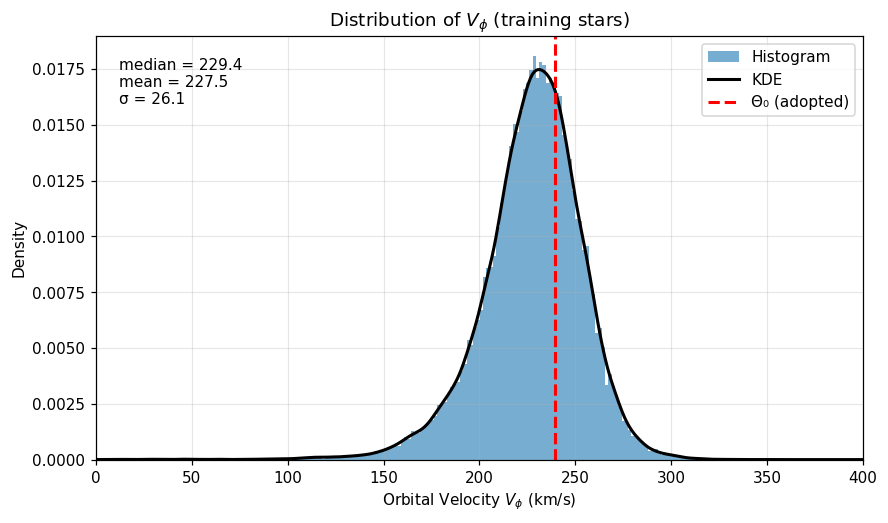

In [11]:
fig, ax = plt.subplots()
ax.hist(train.vphi, bins=200, density=True, alpha=0.6, color="tab:blue", label="Histogram")
grid = np.linspace(0, 400, 400)
ax.plot(grid, gaussian_kde(train.vphi)(grid), color="k", lw=2, label="KDE")
ax.axvline(SUN["Theta0"], color="r", ls="--", lw=2, label="Θ₀ (adopted)")
ax.text(0.03, 0.95, f"median = {train.vphi.median():.1f}\nmean = {train.vphi.mean():.1f}\nσ = {train.vphi.std():.1f}",
        transform=ax.transAxes, va="top")
ax.set(xlim=(0, 400), xlabel="Orbital Velocity $V_\\phi$ (km/s)", ylabel="Density", title="Distribution of $V_\\phi$ (training stars)")
ax.legend(); plt.show()

The distribution peaks just below the adopted circular speed and has a longer tail toward low velocities. This asymmetry is real physics, not noise. Stars on more eccentric orbits spend most of their time near apocenter, where they move more slowly, so any stellar population lags slightly behind the true circular speed — an effect called **asymmetric drift** (Binney & Tremaine 2008, §4.8.2). For the relatively young, cold disk stars that dominate this sample the lag is only a few km/s, but it is the reason we use the **median** velocity in each radial bin rather than the mean.

# Building the Rotation Curve

The scatter plot of every star is informative but noisy: at any radius, stars have a spread of roughly 20–30 km/s in $V_\phi$. To compare models fairly, we collapse the stars into radial bins and take the **median** $V_\phi$ in each bin. The uncertainty on each median comes from bootstrap resampling (re-drawing the stars in that bin with replacement 200 times), and bins with fewer than 20 stars are dropped.

Of course, with thousands of stars per bin the statistical uncertainty becomes tiny — often below 1 km/s. But the truth is that the Milky Way is not a perfect axisymmetric disk: spiral arms and the central bar push stars around by several km/s, and our solar parameters carry their own errors. We therefore add a **systematic floor** $\sigma_{\rm sys}$ in quadrature, so that each bin's total uncertainty is $\sigma_i^2 = \sigma_{{\rm stat},i}^2 + \sigma_{\rm sys}^2$. Eilers et al. (2019) found systematic uncertainties of a few km/s in a similar analysis, so we default to `SIGMA_SYS = 3` km/s.

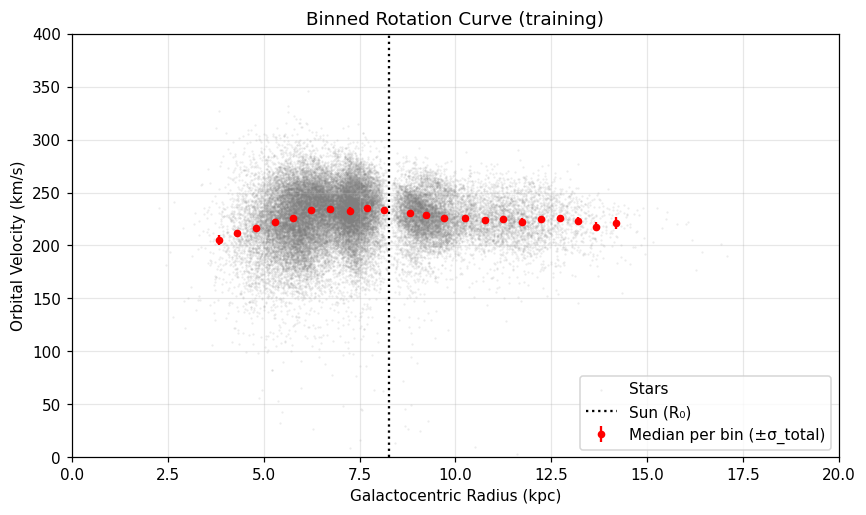

,R,V,sigma_stat,n
0,3.84,205.30,3.83,97
1,4.32,211.39,1.97,384
2,4.79,216.36,0.74,1087
3,5.29,222.04,0.57,2555
4,5.78,226.06,0.47,4544
5,6.23,233.07,0.44,4809
6,6.74,234.22,0.32,4080
7,7.25,232.99,0.37,5773
8,7.69,235.18,0.58,3302
9,8.15,233.30,1.34,559


In [12]:
def bin_rotation_curve(R, v, width=0.5, rmax=20.0, nmin=20, nboot=200, seed=2025):
    rng = np.random.default_rng(seed)
    R, v = np.asarray(R), np.asarray(v)
    rows = []
    for lo in np.arange(0, rmax, width):
        m = (R >= lo) & (R < lo + width)
        n = m.sum()
        if n < nmin:
            continue
        vb = v[m]
        boot = np.median(rng.choice(vb, (nboot, n)), axis=1)
        rows.append((np.median(R[m]), np.median(vb), boot.std(ddof=1), n))
    return pd.DataFrame(rows, columns=["R", "V", "sigma_stat", "n"])

bins_train = bin_rotation_curve(train.R, train.vphi, width=BIN_WIDTH)
sig_tot = lambda b: np.sqrt(b.sigma_stat**2 + SIGMA_SYS**2)

def star_scatter(ax, df, xmax=20, ymax=400, alpha=0.15):
    ax.scatter(df.R, df.vphi, s=2, alpha=alpha, color="gray", lw=0, label="Stars", rasterized=True)
    ax.set(xlim=(0, xmax), ylim=(0, ymax), xlabel="Galactocentric Radius (kpc)", ylabel="Orbital Velocity (km/s)")

fig, ax = plt.subplots()
star_scatter(ax, train)
ax.errorbar(bins_train.R, bins_train.V, sig_tot(bins_train), fmt="o", color="r", ms=4, label="Median per bin (±σ_total)")
ax.axvline(SUN["R0"], ls=":", color="k", label="Sun (R₀)")
ax.set_title("Binned Rotation Curve (training)"); ax.legend(loc="lower right"); plt.show()
bins_train.round(2)

Two gaps are worth pointing out. There are very few stars inside ~4 kpc, because a $5\sigma$ parallax cut limits us to stars within a few kpc of the Sun. Similarly, the points thin out beyond ~15 kpc for the same reason. This means that the data genuinely constrain the curve only between about 4 and 15 kpc — something we need to keep in mind before we draw conclusions about the bulge or the outer halo.

## The models and the fitting machinery

All five models are defined here once, so that every section below scores them with the same χ² against the same bins. The physics of each model is explained in its own section.

In [13]:
G = 4.30091e-6          # kpc (km/s)^2 / M_sun

def v_kepler(R, p): return np.sqrt(G * p[0] * 1e10 / np.asarray(R))           # p = [M / 1e10 M_sun]
def v_linear(R, p): return p[0] + p[1] * (np.asarray(R) - SUN["R0"])         # p = [V0, dV/dR], pivot at R0
def v_simple(R, p): return p[0] * (1 - np.exp(-p[1] * np.asarray(R)))         # p = [V_inf, S]

def v_hernquist(R, M, a): return np.sqrt(G * M * R) / (R + a)

def v_freeman(R, Sigma0, Rd):          # Sigma0 in M_sun/kpc^2
    R = np.maximum(np.asarray(R, float), 1e-6)
    y = R / (2 * Rd)
    v2 = 4 * np.pi * G * Sigma0 * Rd * y**2 * (i0(y) * k0(y) - i1(y) * k1(y))
    return np.sqrt(np.maximum(v2, 0))

def v_nfw(R, rho0, rs):                 # rho0 in M_sun/kpc^3
    R = np.maximum(np.asarray(R, float), 1e-6)
    x = R / rs
    return np.sqrt(4 * np.pi * G * rho0 * rs**3 * (np.log1p(x) - x / (1 + x)) / R)

# Fixed components (McMillan 2017, simplified)
BULGE   = dict(M=9.0e9, a=0.5)
HI_DISK = dict(Sigma0=1.1e10 / (2 * np.pi * 7.0**2), Rd=7.0)
H2_DISK = dict(Sigma0=1.2e9 / (2 * np.pi * 1.5**2), Rd=1.5)
RS_HALO = 19.6

def mw_components(R, p):
    """p = [Sigma0 / 1e8 M_sun kpc^-2, R_d / kpc, rho0 / 1e7 M_sun kpc^-3]"""
    R = np.asarray(R, float)
    return dict(bulge=v_hernquist(R, BULGE["M"], BULGE["a"]),
                disk=v_freeman(R, p[0] * 1e8, p[1]),
                HI=v_freeman(R, HI_DISK["Sigma0"], HI_DISK["Rd"]),
                H2=v_freeman(R, H2_DISK["Sigma0"], H2_DISK["Rd"]),
                halo=v_nfw(R, p[2] * 1e7, RS_HALO))

def v_complex(R, p):
    return np.sqrt(sum(v**2 for v in mw_components(R, p).values()))

def chi2(f, p, b, sigma_sys=SIGMA_SYS):
    return float(np.sum((b.V - f(b.R.values, p))**2 / (b.sigma_stat**2 + sigma_sys**2)))

class Fit:
    """Weighted least squares with scipy; mirrors the LsqFit.jl result used in the Pluto version."""
    def __init__(self, f, b, p0, bounds=(-np.inf, np.inf), prior=None, sigma_sys=SIGMA_SYS, track=False):
        s = np.sqrt(b.sigma_stat.values**2 + sigma_sys**2)
        self.history = []
        def resid(p):
            if track:
                self.history.append(np.array(p))
            r = (b.V.values - f(b.R.values, p)) / s
            if prior is not None:                      # (index, mean, sigma) Gaussian prior
                i, mu, sd = prior
                r = np.append(r, (p[i] - mu) / sd)
            return r
        res = least_squares(resid, np.asarray(p0, float), bounds=bounds, method="trf", x_scale="jac")
        self.param, self.converged = res.x, res.success
        J = res.jac
        self.cov = np.linalg.pinv(J.T @ J)
        self.err = np.sqrt(np.diag(self.cov))

def fit_all_models(b, sigma_sys=SIGMA_SYS, rd_prior=USE_RD_PRIOR):
    return dict(
        Keplerian=Fit(v_kepler, b, [10.0], ([0.01], [1000.0]), sigma_sys=sigma_sys),
        Linear=Fit(v_linear, b, [230.0, 0.0], sigma_sys=sigma_sys),
        Simple=Fit(v_simple, b, [230.0, 0.5], ([50, 0.01], [500, 20]), sigma_sys=sigma_sys),
        Complex=Fit(v_complex, b, [8.96, 2.5, 0.854], ([0.1, 0.5, 0.01], [100, 10, 20]),
                    prior=(1, 2.6, 0.5) if rd_prior else None, sigma_sys=sigma_sys, track=True))

MODEL_FUNCS = dict(Keplerian=v_kepler, Linear=v_linear, Simple=v_simple, Complex=v_complex)
fits = fit_all_models(bins_train)

def fit_table_for(fits, b):
    n, rows = len(b), []
    for name, ft in fits.items():
        k, c = len(ft.param), chi2(MODEL_FUNCS[name], ft.param, b)
        rows.append(dict(model=name, k=k, chi2=c, dof=n - k, chi2_red=c / (n - k), AIC=c + 2 * k, BIC=c + k * np.log(n)))
    t = pd.DataFrame(rows)
    t["dBIC"] = t.BIC - t.BIC.min()
    return t

fit_table = fit_table_for(fits, bins_train)

In [14]:
def plot_residuals(df, b, f, p, xmax=20, title="Residuals: Observed − Model"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.scatter(df.R, df.vphi - f(df.R.values, p), s=2, alpha=0.12, lw=0, color="gray", label="Individual stars", rasterized=True)
    ax.errorbar(b.R, b.V - f(b.R.values, p), b.sigma_stat, fmt="o", color="r", ms=4, label="Binned medians")
    ax.axhline(0, color="k", ls="--", lw=2, label="Zero Residual")
    ax.set(xlim=(0, xmax), ylim=(-120, 120), xlabel="Galactocentric Radius (kpc)", ylabel="Residual (km/s)", title=title)
    ax.legend(loc="lower left"); plt.show()

def chi2_heatmap(f, b, yrange, xrange, xlabel, ylabel, title, best):
    Mx = np.array([[chi2(f, [y, x], b) for x in xrange] for y in yrange])
    iy, ix = np.unravel_index(np.argmin(Mx), Mx.shape)
    fig, ax = plt.subplots()
    pc = ax.pcolormesh(xrange, yrange, np.log10(Mx), cmap="viridis", shading="auto")
    fig.colorbar(pc, label="log₁₀ χ²")
    ax.plot(xrange[ix], yrange[iy], "o", color="r", ms=8, label=f"Grid minimum (χ² = {Mx.min():.1f})")
    ax.plot(best[1], best[0], "*", color="w", ms=14, mec="k", label="Least-squares fit")
    ax.set(xlabel=xlabel, ylabel=ylabel, title=title); ax.legend(); plt.show()

# The Keplerian Orbit

As we know, Keplerian orbits are a fundamental part of Newtonian physics, and they give us a baseline to test against. If nearly all of the galaxy's mass were concentrated at its center — the way the Sun dominates the Solar System — the orbital speed would fall off with distance as

$V_{\text{Keplerian}}(R) = \sqrt{\frac{GM_{\text{enclosed}}}{R}}$

Where: $V_{\text{Keplerian}}$ is the orbital velocity in km/s

Where: $M_{\text{enclosed}}$ is the mass that the stars orbit, in solar masses

Where: $R$ is the distance from that mass, in kpc, and $G = 4.30091 \times 10^{-6}$ kpc (km/s)² / M☉

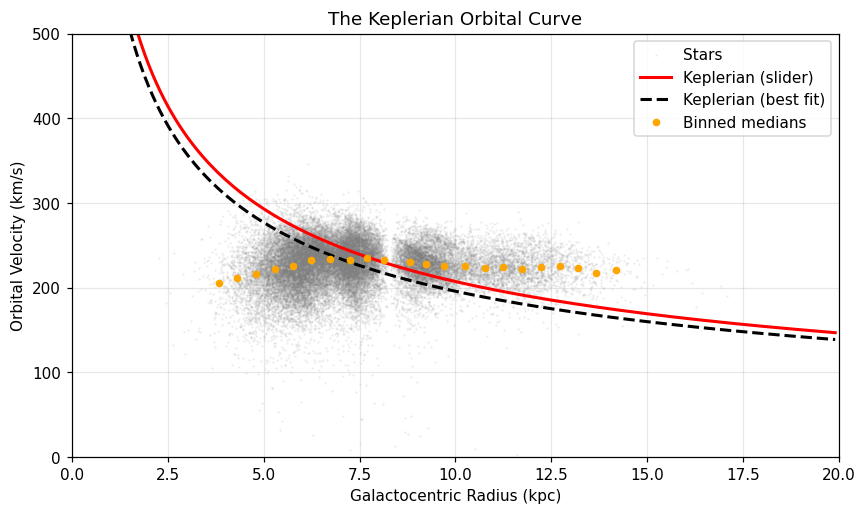

In [15]:
def explore_kepler(mass=1e11, xmax=20):
    fig, ax = plt.subplots()
    star_scatter(ax, train, xmax, 500)
    r = np.arange(0.1, xmax, 0.1)
    ax.plot(r, v_kepler(r, [mass / 1e10]), "r", lw=2, label="Keplerian (slider)")
    ax.plot(r, v_kepler(r, fits["Keplerian"].param), "k--", lw=2, label="Keplerian (best fit)")
    ax.plot(bins_train.R, bins_train.V, "o", color="orange", ms=4, label="Binned medians")
    ax.set_title("The Keplerian Orbital Curve"); ax.legend(loc="upper right"); plt.show()

explore_kepler()

In [16]:
# Interactive version (works when the notebook is running)
if HAVE_WIDGETS:
    interact(explore_kepler, mass=FloatSlider(value=1e11, min=1e10, max=3e11, step=1e10, readout_format=".1e", description="M_enc (M☉)"),
             xmax=IntSlider(value=20, min=1, max=30, description="Max R (kpc)"));

In [17]:
display(Markdown(f"""The best-fitting point mass is $M = {fits['Keplerian'].param[0] * 1e10:.2e}$ M☉, but it is a poor description: its reduced χ² is **{fit_table.chi2_red[0]:.1f}**. Needless to say, the rotation of the galaxy is not bound by Keplerian parameters. The mass of the Milky Way is spread throughout its disk and halo, so the enclosed mass keeps growing with radius, and the curve stays nearly flat instead of falling."""))

The best-fitting point mass is $M = 8.93e+10$ M☉, but it is a poor description: its reduced χ² is **175.1**. Needless to say, the rotation of the galaxy is not bound by Keplerian parameters. The mass of the Milky Way is spread throughout its disk and halo, so the enclosed mass keeps growing with radius, and the curve stays nearly flat instead of falling.

# A Linear Regression Fit

The simplest description of a nearly flat curve is a straight line. We write it around the Sun's position,

$V(R) = V_0 + \frac{dV}{dR}\,(R - R_0),$

so that $V_0$ is the circular speed at the Sun and $dV/dR$ is the local slope. Writing it this way (instead of using the intercept at $R = 0$, as the first version did) makes both parameters physically meaningful and much less correlated. It also lets us compare directly to Eilers et al. (2019), who measured $V_0 = 229.0 \pm 0.2$ km/s and a gentle decline of $-1.7 \pm 0.1$ km/s/kpc between 5 and 25 kpc, using $R_0 = 8.122$ kpc.

> **Tip:** move $V_0$ and the gradient in the interactive cell to center the residuals on 0 and minimise χ². Then compare your answer to the least-squares fit.

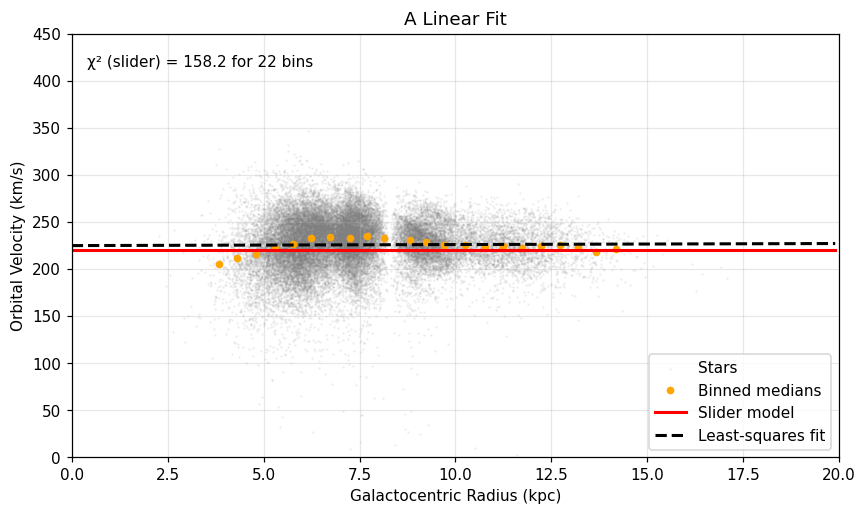

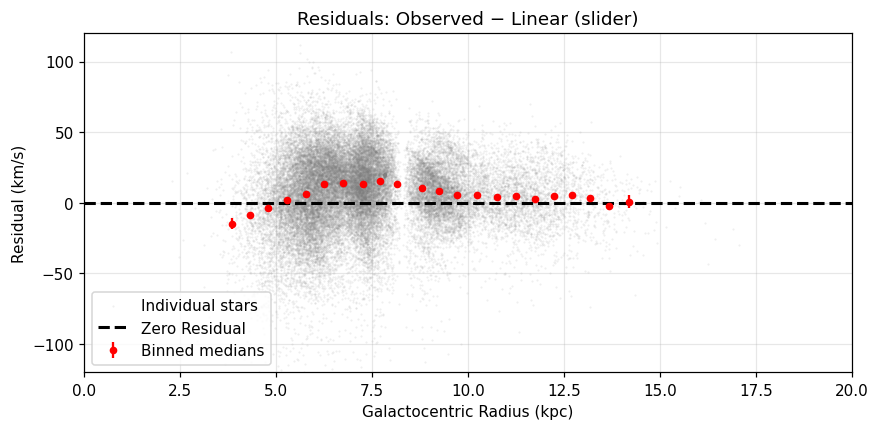

In [18]:
def explore_linear(v0=220.0, grad=0.0, xmax=20):
    p = [v0, grad]
    fig, ax = plt.subplots()
    star_scatter(ax, train, xmax, 450)
    ax.plot(bins_train.R, bins_train.V, "o", color="orange", ms=4, label="Binned medians")
    r = np.arange(0, xmax, 0.1)
    ax.plot(r, v_linear(r, p), "r", lw=2, label="Slider model")
    ax.plot(r, v_linear(r, fits["Linear"].param), "k--", lw=2, label="Least-squares fit")
    ax.text(0.02, 0.95, f"χ² (slider) = {chi2(v_linear, p, bins_train):.1f} for {len(bins_train)} bins", transform=ax.transAxes, va="top")
    ax.set_title("A Linear Fit"); ax.legend(loc="lower right"); plt.show()
    plot_residuals(train, bins_train, v_linear, p, xmax, "Residuals: Observed − Linear (slider)")

explore_linear()

In [19]:
if HAVE_WIDGETS:
    interact(explore_linear, v0=FloatSlider(value=220, min=180, max=280, step=1, description="V₀ (km/s)"),
             grad=FloatSlider(value=0, min=-10, max=10, step=0.1, description="dV/dR"),
             xmax=IntSlider(value=20, min=1, max=30, description="Max R (kpc)"));

In [20]:
p, e = fits["Linear"].param, fits["Linear"].err
display(Markdown(f"""**Least-squares linear fit:** $V_0$ = {p[0]:.1f} ± {e[0]:.1f} km/s, slope = {p[1]:.2f} ± {e[1]:.2f} km/s/kpc, reduced χ² = {fit_table.chi2_red[1]:.2f}.

The binned residuals are the real test here. If they curve up and down in a systematic pattern (rising inside ~7 kpc and flattening outside), then a straight line is missing some structure in the data, even if its overall χ² looks acceptable."""))

**Least-squares linear fit:** $V_0$ = 225.8 ± 0.7 km/s, slope = 0.11 ± 0.24 km/s/kpc, reduced χ² = 4.42.

The binned residuals are the real test here. If they curve up and down in a systematic pattern (rising inside ~7 kpc and flattening outside), then a straight line is missing some structure in the data, even if its overall χ² looks acceptable.

### χ² of the Linear Model
How the χ² varies with the two parameters of the linear model.

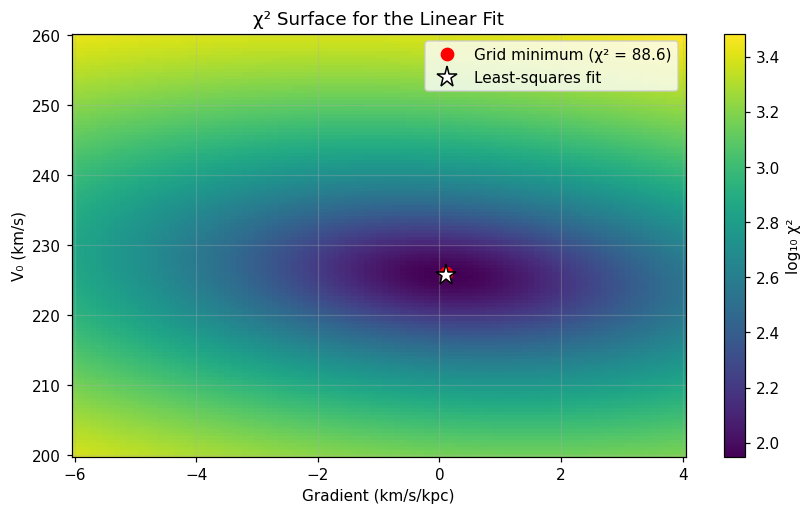

In [21]:
chi2_heatmap(v_linear, bins_train, np.arange(200, 260.5, 0.5), np.arange(-6, 4.05, 0.1),
             "Gradient (km/s/kpc)", "V₀ (km/s)", "χ² Surface for the Linear Fit", fits["Linear"].param)

# A Simple Model

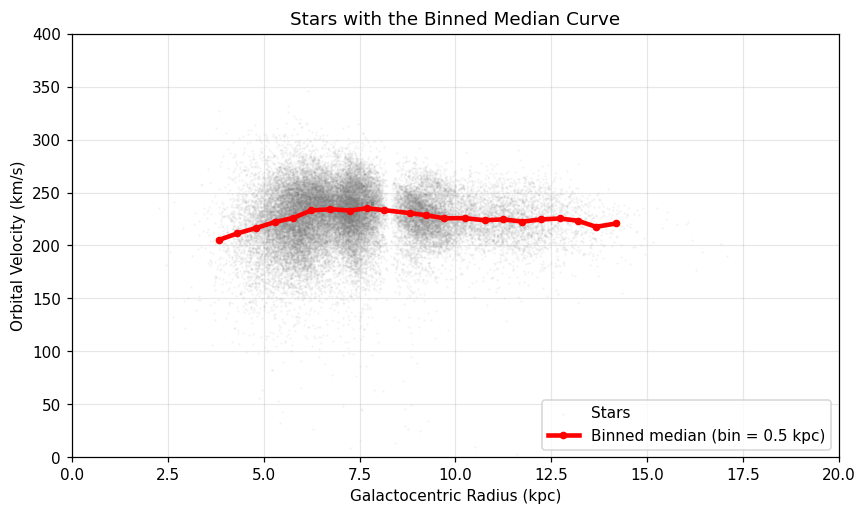

In [22]:
fig, ax = plt.subplots()
star_scatter(ax, train, alpha=0.1)
ax.plot(bins_train.R, bins_train.V, "o-", color="r", lw=3, ms=4, label=f"Binned median (bin = {BIN_WIDTH} kpc)")
ax.set_title("Stars with the Binned Median Curve"); ax.legend(loc="lower right"); plt.show()

The binned curve gives us a rough idea of a two-parameter function that could be fitted. It rises in the inner galaxy and then flattens out, which is the classic shape of a disk galaxy's rotation curve. One of the simplest approximations for this shape is

$$f(R) = V_{\infty} \left( 1 - e^{-S R} \right)$$

where $V_\infty$ is the speed that the curve flattens to and $S$ (in kpc⁻¹) controls how quickly it gets there. This function has no physical derivation behind it — it is purely descriptive — but it is a useful stepping stone between a straight line and a real mass model.

> **Tip:** move the velocity and scaling factor in the interactive cell to center the residuals on 0 and reach the smallest χ².

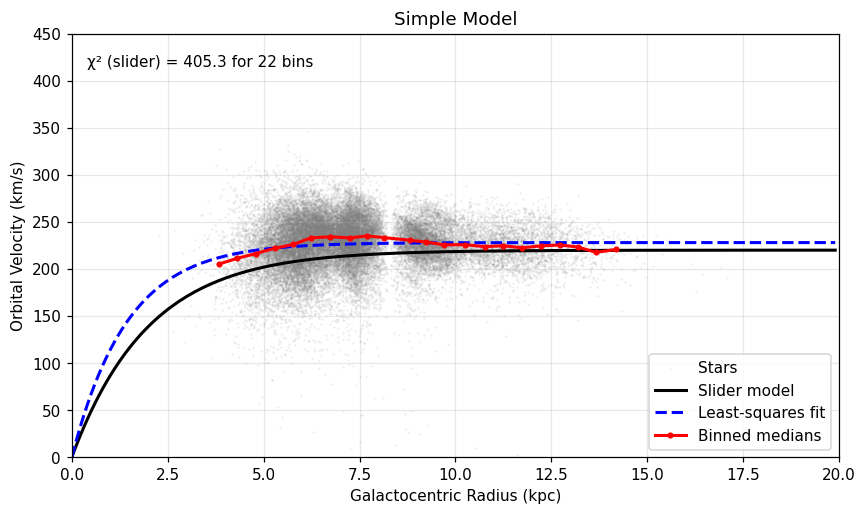

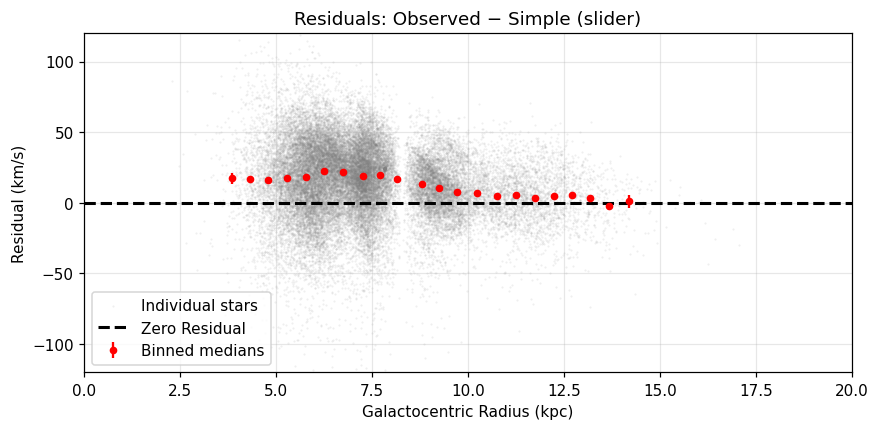

In [23]:
def explore_simple(v_inf=220.0, s=0.5, xmax=20):
    p = [v_inf, s]
    fig, ax = plt.subplots()
    star_scatter(ax, train, xmax, 450)
    r = np.arange(0, xmax, 0.1)
    ax.plot(r, v_simple(r, p), "k", lw=2, label="Slider model")
    ax.plot(r, v_simple(r, fits["Simple"].param), "b--", lw=2, label="Least-squares fit")
    ax.plot(bins_train.R, bins_train.V, "o-", color="r", ms=3, lw=2, label="Binned medians")
    ax.text(0.02, 0.95, f"χ² (slider) = {chi2(v_simple, p, bins_train):.1f} for {len(bins_train)} bins", transform=ax.transAxes, va="top")
    ax.set_title("Simple Model"); ax.legend(loc="lower right"); plt.show()
    plot_residuals(train, bins_train, v_simple, p, xmax, "Residuals: Observed − Simple (slider)")

explore_simple()

In [24]:
if HAVE_WIDGETS:
    interact(explore_simple, v_inf=FloatSlider(value=220, min=180, max=270, step=1, description="V∞ (km/s)"),
             s=FloatSlider(value=0.5, min=0.05, max=3, step=0.05, description="S (1/kpc)"),
             xmax=IntSlider(value=20, min=1, max=30, description="Max R (kpc)"));

### χ² of the Simple Model
How the χ² varies with the two parameters of the simple model.

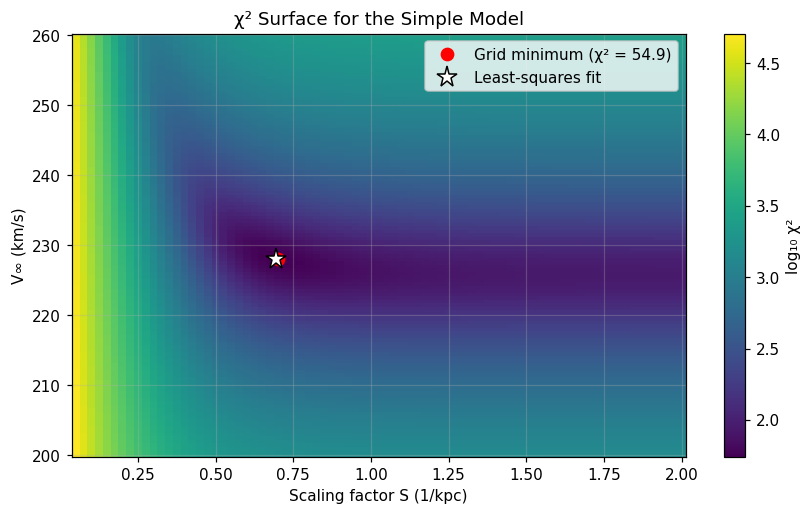

In [25]:
chi2_heatmap(v_simple, bins_train, np.arange(200, 260.5, 0.5), np.arange(0.05, 2.0001, 0.025),
             "Scaling factor S (1/kpc)", "V∞ (km/s)", "χ² Surface for the Simple Model", fits["Simple"].param)

# A Complex Model - The Dark Matter-corrected Milky Way Rotation Curve

The total rotation curve of the Milky Way is the quadrature sum of the contributions from each of its mass components, because the gravitational forces (and therefore the squared circular speeds) simply add:

$V_{\text{total}}(R) = \sqrt{V_{\text{bulge}}^2 + V_{\text{disk}}^2 + V_{\text{HI}}^2 + V_{\text{H2}}^2 + V_{\text{halo}}^2}$

The first version followed the same five-component picture (Ueshima 2010), but used ad-hoc formulas with ten free parameters. While ten knobs might sound more realistic, there are complexities in this matter that must be addressed: several of those formulas did not have units of velocity, and our data only cover about 4–15 kpc, which is far too narrow to separate ten parameters. The fit would drift almost anywhere without the χ² noticing. This version uses the standard, physically derived profile for each component (Binney & Tremaine 2008), fixes the pieces our data cannot constrain at literature values from Paul McMillan's widely used Milky Way mass model (McMillan 2017), and fits only **three** parameters.

#### **1. Bulge (Blue Line) — Hernquist sphere, fixed**
$V_{\text{bulge}}(R) = \frac{\sqrt{G M_b R}}{R + a}$

with $M_b = 9 \times 10^9$ M☉ (McMillan 2017) and $a = 0.5$ kpc (Hernquist 1990). Our data barely reach the bulge, so it is held fixed.

#### **2. Stellar Disk (Green Line) — Freeman exponential disk, fitted**
An infinitely thin disk with surface density $\Sigma(R) = \Sigma_0 e^{-R/R_d}$ has the exact rotation curve (Freeman 1970)

$V_{\text{disk}}^2(R) = 4\pi G \Sigma_0 R_d\, y^2 \left[I_0(y)K_0(y) - I_1(y)K_1(y)\right], \qquad y = \frac{R}{2R_d}$

where $I_n$ and $K_n$ are modified Bessel functions. **$\Sigma_0$ and $R_d$ are free.** The total disk mass is $M_d = 2\pi\Sigma_0 R_d^2$.

#### **3. HI Layer (Yellow Line) — Freeman disk, fixed**
Neutral atomic hydrogen, with $M_{\rm HI} = 1.1 \times 10^{10}$ M☉ and $R_d = 7$ kpc (approximating McMillan 2017, without its central hole).

#### **4. H2 Layer (Pink Line) — Freeman disk, fixed**
Molecular hydrogen, with $M_{\rm H_2} = 1.2 \times 10^{9}$ M☉ and $R_d = 1.5$ kpc (same approximation). Both gas layers contribute only ~10–30 km/s, so these simplifications barely matter.

#### **5. Dark Halo (Grey Line) — NFW profile, fitted**
Cosmological simulations predict dark matter halos with the Navarro–Frenk–White density profile (Navarro, Frenk & White 1996), $\rho(r) = \rho_0 / [x(1+x)^2]$ with $x = r/r_s$, which gives

$V_{\text{halo}}^2(r) = \frac{4\pi G \rho_0 r_s^3}{r}\left[\ln(1+x) - \frac{x}{1+x}\right]$

**$\rho_0$ is free**; the scale radius is fixed at $r_s = 19.6$ kpc (McMillan 2017), since it lies well outside our data.

#### **6. Final Estimation (Black Line)**
$V_{\text{total}}(R)$ is the quadrature sum. Below is a plot of the model at the McMillan (2017) starting values, followed by an interactive version with adjustable mass normalisations.

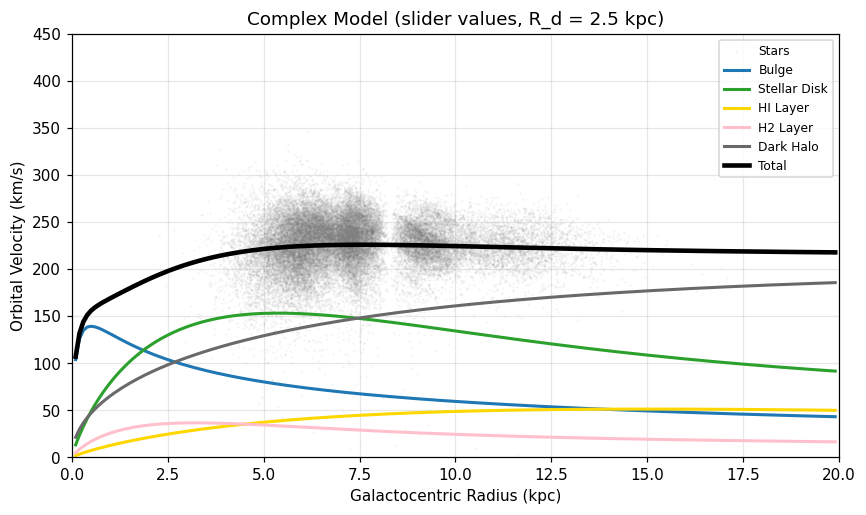

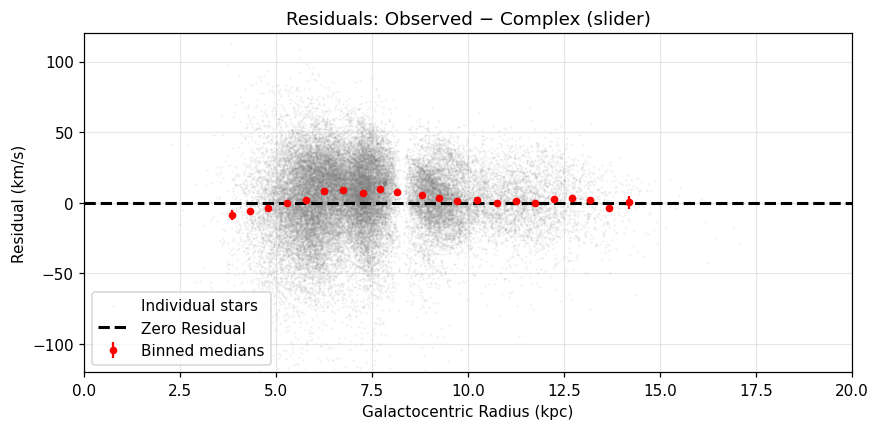

In [26]:
def plot_components(df, p, xmax=20, title="Complex Model", bins=None):
    r = np.arange(0.1, xmax, 0.1)
    c = mw_components(r, p)
    fig, ax = plt.subplots()
    star_scatter(ax, df, xmax, 450, alpha=0.1)
    for key, col, lab in [("bulge", "tab:blue", "Bulge"), ("disk", "tab:green", "Stellar Disk"), ("HI", "gold", "HI Layer"),
                          ("H2", "pink", "H2 Layer"), ("halo", "dimgray", "Dark Halo")]:
        ax.plot(r, c[key], color=col, lw=2, label=lab)
    ax.plot(r, v_complex(r, p), "k", lw=3, label="Total")
    if bins is not None:
        ax.errorbar(bins.R, bins.V, sig_tot(bins), fmt="o", color="r", ms=3, label="Binned medians")
    ax.set_title(title); ax.legend(loc="upper right", fontsize=8); plt.show()

def explore_complex(sigma0=900, rho0=8.5, xmax=20):
    p = [sigma0 / 100, 2.5, rho0 / 10]      # internal units: 1e8 M_sun/kpc^2, kpc, 1e7 M_sun/kpc^3
    plot_components(train, p, xmax, "Complex Model (slider values, R_d = 2.5 kpc)")
    plot_residuals(train, bins_train, v_complex, p, xmax, "Residuals: Observed − Complex (slider)")

explore_complex(896, 8.54)

In [27]:
if HAVE_WIDGETS:
    interact(explore_complex, sigma0=FloatSlider(value=900, min=200, max=2000, step=20, description="Σ₀ (M☉/pc²)"),
             rho0=FloatSlider(value=8.5, min=1, max=30, step=0.5, description="ρ₀ (1e-3 M☉/pc³)"),
             xmax=IntSlider(value=20, min=1, max=30, description="Max R (kpc)"));

## A Non-Linear Regression Fit for the Three Free Parameters

## Nonlinear Least Squares Fit to the Galactic Rotation Curve

Here with the complex model, we fit a physical model of galactic rotation to the binned *Gaia* curve. The model predicts the circular velocity $V_{\text{model}}$ as a function of Galactocentric radius $R$ and the parameter vector $\boldsymbol{\theta} = (\Sigma_0, R_d, \rho_0)$.

### Observed Data

$R_i$ — median Galactocentric radius of bin $i$

$V_{\text{obs}, i}$ — median orbital velocity of bin $i$

$\sigma_i$ — total uncertainty of bin $i$ (bootstrap plus systematic floor)

### Optimization Objective

We look for the parameters that minimise the *weighted* squared differences — the true χ²:

$\boldsymbol{\theta}^* = \arg\min_{\boldsymbol{\theta}} \sum_{i=1}^{n} \frac{\left( V_{\text{model}}(R_i; \boldsymbol{\theta}) - V_{\text{obs}, i} \right)^2}{\sigma_i^2} \; + \; \frac{(R_d - 2.6)^2}{0.5^2}$

The last term is an optional **Gaussian prior** on the disk scale length from the review by Joss Bland-Hawthorn and Ortwin Gerhard, which compiled decades of star-count measurements into $R_d = 2.6 \pm 0.5$ kpc (Bland-Hawthorn & Gerhard 2016). It exists because disks and halos are famously degenerate in rotation-curve fitting: a heavier disk and a lighter halo can produce almost the same curve. The minimisation uses `scipy.optimize.least_squares`, (here, SciPy's trust-region least squares) with parameter bounds that keep every mass positive. Set `USE_RD_PRIOR` in the settings cell to switch the prior on or off.

> **Starting point** (McMillan 2017 thin disk and halo): Σ₀ = 896 M☉/pc², $R_d$ = 2.5 kpc, ρ₀ = 0.00854 M☉/pc³.

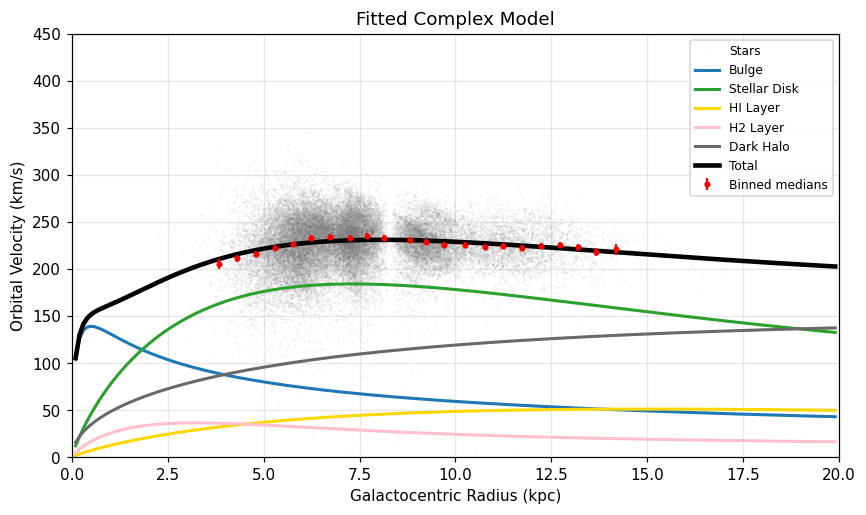

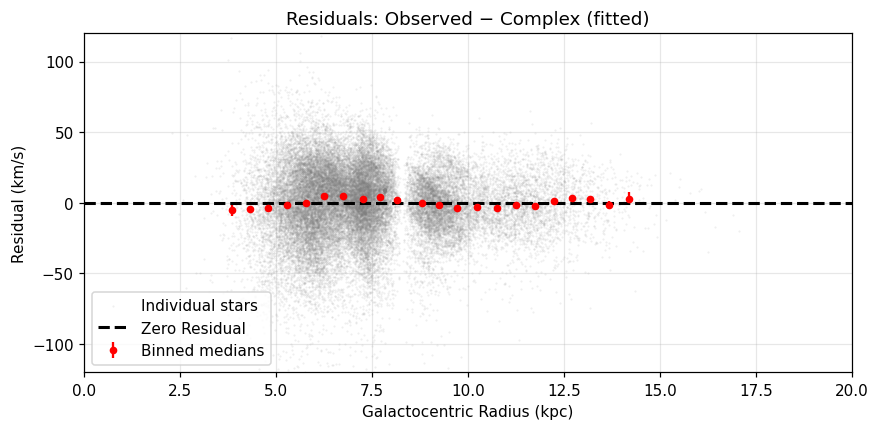

### Recovered Parameters from Gaia Data
| Parameter | Fitted value | McMillan (2017) |
|:--|--:|--:|
| Disk central surface density Σ₀ | 951 ± 52 M☉/pc² | 896 M☉/pc² |
| Disk scale length $R_d$ | 3.41 ± 0.24 kpc | 2.50 kpc |
| Halo density ρ₀ | 4.69 ± 1.44 × 10⁻³ M☉/pc³ | 8.54 × 10⁻³ M☉/pc³ |
| Optimiser converged? | True | |
| Prior on $R_d$ applied? | True | |

In [28]:
fc = fits["Complex"]
plot_components(train, fc.param, 20, "Fitted Complex Model", bins=bins_train)
plot_residuals(train, bins_train, v_complex, fc.param, 20, "Residuals: Observed − Complex (fitted)")
p, e = fc.param, fc.err
display(Markdown(f"""### Recovered Parameters from Gaia Data
| Parameter | Fitted value | McMillan (2017) |
|:--|--:|--:|
| Disk central surface density Σ₀ | {p[0]*100:.0f} ± {e[0]*100:.0f} M☉/pc² | 896 M☉/pc² |
| Disk scale length $R_d$ | {p[1]:.2f} ± {e[1]:.2f} kpc | 2.50 kpc |
| Halo density ρ₀ | {p[2]*10:.2f} ± {e[2]*10:.2f} × 10⁻³ M☉/pc³ | 8.54 × 10⁻³ M☉/pc³ |
| Optimiser converged? | {fc.converged} | |
| Prior on $R_d$ applied? | {USE_RD_PRIOR} | |"""))

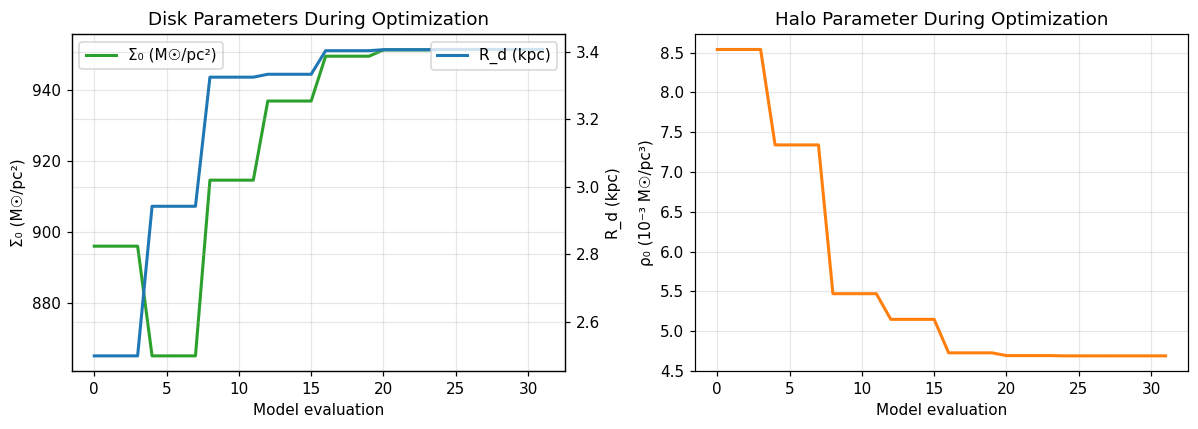

In [29]:
h = np.array(fc.history)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
ax.plot(h[:, 0] * 100, color="tab:green", lw=2, label="Σ₀ (M☉/pc²)")
ax.set(xlabel="Model evaluation", ylabel="Σ₀ (M☉/pc²)", title="Disk Parameters During Optimization")
ax2 = ax.twinx(); ax2.plot(h[:, 1], color="tab:blue", lw=2, label="R_d (kpc)"); ax2.set_ylabel("R_d (kpc)")
ax.legend(loc="upper left"); ax2.legend(loc="upper right")
axes[1].plot(h[:, 2] * 10, color="tab:orange", lw=2)
axes[1].set(xlabel="Model evaluation", ylabel="ρ₀ (10⁻³ M☉/pc³)", title="Halo Parameter During Optimization")
plt.tight_layout(); plt.show()

The history includes every call the optimiser made to the model, including the small parameter nudges it uses to estimate derivatives, which is why the lines look jagged before they settle.

# Comparing the Models Fairly

A model with more parameters will almost always reach a lower χ², so a lower χ² alone does not prove a model is better. The **Akaike** and **Bayesian Information Criteria** add a penalty for each extra parameter $k$:

$\text{AIC} = \chi^2 + 2k, \qquad \text{BIC} = \chi^2 + k \ln n$

where $n$ is the number of bins. Lower is better, and a BIC difference larger than about 10 is generally considered very strong evidence (Kass & Raftery 1995). Every number in this table uses the same bins, the same uncertainties and the same χ² definition.

In [30]:
def model_table_md(t):
    lines = ["| Model | k | χ² | dof | χ²/dof | AIC | BIC | ΔBIC |", "|:--|--:|--:|--:|--:|--:|--:|--:|"]
    lines += [f"| {r.model} | {r.k} | {r.chi2:.1f} | {r.dof} | {r.chi2_red:.2f} | {r.AIC:.1f} | {r.BIC:.1f} | {r.dBIC:.1f} |" for r in t.itertuples()]
    return "\n".join(lines) + f"\n\n**Preferred model by BIC: {t.model[t.BIC.idxmin()]}.**"

display(Markdown(model_table_md(fit_table)))

| Model | k | χ² | dof | χ²/dof | AIC | BIC | ΔBIC |
|:--|--:|--:|--:|--:|--:|--:|--:|
| Keplerian | 1 | 3676.6 | 21 | 175.07 | 3678.6 | 3679.7 | 3651.0 |
| Linear | 2 | 88.5 | 20 | 4.42 | 92.5 | 94.7 | 66.0 |
| Simple | 2 | 54.9 | 20 | 2.74 | 58.9 | 61.1 | 32.4 |
| Complex | 3 | 19.4 | 19 | 1.02 | 25.4 | 28.7 | 0.0 |

**Preferred model by BIC: Complex.**

# Testing Data vs Training Data
For our test data, we use the independent Gaia DR2 stars selected above — stars that are **not** in the training set. We apply exactly the same quality cuts, zero-point correction and Galactocentric transformation (the first version skipped the quality cuts on the test set), bin them the same way, and then ask how well each model **trained on DR3** predicts them, without refitting anything.

Because DR2 has fewer radial velocities than DR3, and half of its stars were reserved for training, the test set is smaller and its bins need at least 10 stars instead of 20.

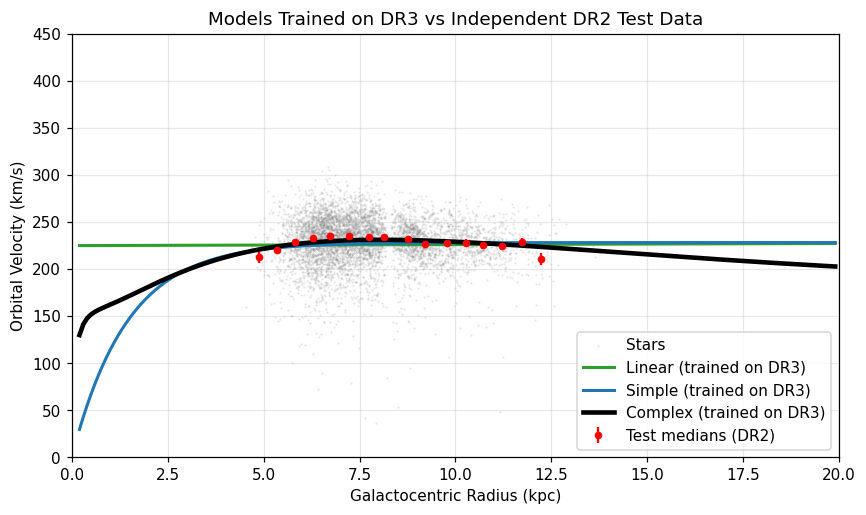

### Out-of-sample performance on the independent DR2 stars (16 bins)
| Model (trained on DR3) | χ² on test | χ² per bin |
|:--|--:|--:|
| Keplerian | 1081.7 | 67.61 |
| Linear | 53.7 | 3.36 |
| Simple | 45.5 | 2.85 |
| Complex | 19.2 | 1.20 |

In [31]:
bins_test = bin_rotation_curve(test_all.R, test_all.vphi, width=BIN_WIDTH, nmin=10)

fig, ax = plt.subplots()
star_scatter(ax, test_all, 20, 450, alpha=0.2)
ax.errorbar(bins_test.R, bins_test.V, sig_tot(bins_test), fmt="o", color="r", ms=4, label="Test medians (DR2)")
r = np.arange(0.2, 20, 0.1)
for name, col, lw in [("Linear", "tab:green", 2), ("Simple", "tab:blue", 2), ("Complex", "k", 3)]:
    ax.plot(r, MODEL_FUNCS[name](r, fits[name].param), color=col, lw=lw, label=f"{name} (trained on DR3)")
ax.set_title("Models Trained on DR3 vs Independent DR2 Test Data"); ax.legend(loc="lower right"); plt.show()

test_table = pd.DataFrame([dict(model=m, chi2_test=chi2(MODEL_FUNCS[m], ft.param, bins_test)) for m, ft in fits.items()])
test_table["chi2_test_per_bin"] = test_table.chi2_test / max(len(bins_test), 1)
md = [f"### Out-of-sample performance on the independent DR2 stars ({len(bins_test)} bins)",
      "| Model (trained on DR3) | χ² on test | χ² per bin |", "|:--|--:|--:|"]
md += [f"| {r.model} | {r.chi2_test:.1f} | {r.chi2_test_per_bin:.2f} |" for r in test_table.itertuples()]
if len(bins_test) < 5:
    md.append(f"\n⚠️ Only {len(bins_test)} test bins survived — too few for a meaningful comparison.")
display(Markdown("\n".join(md)))

In [32]:
rows = [("Linear $V_0$ (km/s)", "Linear", 0, 1), ("Linear slope (km/s/kpc)", "Linear", 1, 1),
        ("Simple $V_\\infty$ (km/s)", "Simple", 0, 1), ("Simple $S$ (1/kpc)", "Simple", 1, 1),
        ("Complex Σ₀ (M☉/pc²)", "Complex", 0, 100), ("Complex $R_d$ (kpc)", "Complex", 1, 1),
        ("Complex ρ₀ (10⁻³ M☉/pc³)", "Complex", 2, 10)]
if len(bins_test) >= 4:
    refit = fit_all_models(bins_test)
    fmt = lambda ft, i, s: f"{ft.param[i]*s:.2f} ± {ft.err[i]*s:.2f}"
    md = ["### Do the fitted parameters hold up?", "| Parameter | Trained on DR3 | Refit on DR2 test |", "|:--|--:|--:|"]
    md += [f"| {n} | {fmt(fits[m], i, s)} | {fmt(refit[m], i, s)} |" for n, m, i, s in rows]
    display(Markdown("\n".join(md)))
else:
    display(Markdown("Too few test bins to refit the models on the test set alone."))

### Do the fitted parameters hold up?
| Parameter | Trained on DR3 | Refit on DR2 test |
|:--|--:|--:|
| Linear $V_0$ (km/s) | 225.76 ± 0.71 | 229.41 ± 0.89 |
| Linear slope (km/s/kpc) | 0.11 ± 0.24 | -0.84 ± 0.44 |
| Simple $V_\infty$ (km/s) | 228.06 ± 0.89 | 229.81 ± 1.15 |
| Simple $S$ (1/kpc) | 0.69 ± 0.05 | 0.83 ± 0.20 |
| Complex Σ₀ (M☉/pc²) | 951.43 ± 52.41 | 1066.56 ± 86.38 |
| Complex $R_d$ (kpc) | 3.41 ± 0.24 | 3.29 ± 0.38 |
| Complex ρ₀ (10⁻³ M☉/pc³) | 4.69 ± 1.44 | 3.93 ± 2.55 |

The second table asks a slightly different question: if we refit each model on the test stars alone, do we recover the same parameters? Agreement within the uncertainties means the trends we found are properties of the Galaxy rather than of one particular sample. A disagreement is still a useful result, and it is exactly the kind of null or negative outcome that should be reported rather than hidden.

# Conclusion

In [33]:
t = fit_table.sort_values("BIC").reset_index(drop=True)
best, second, dBIC = t.model[0], t.model[1], t.BIC[1] - t.BIC[0]
strength = (", which counts as very strong evidence" if dBIC > 10 else
            ", which is positive but not overwhelming evidence" if dBIC > 2 else ", which is not a decisive difference")
lin = fits["Linear"].param
vc0 = float(v_complex(SUN["R0"], fits["Complex"].param))
txt = f"""Across the training bins, the **{best}** model is preferred by the Bayesian Information Criterion, ahead of the {second} model by ΔBIC = {dBIC:.1f}{strength}. The Keplerian point-mass curve is ruled out by a wide margin, which is the classic signature that the Milky Way's mass keeps growing well beyond its bright center.

The linear fit gives a circular speed of **{lin[0]:.1f} km/s** at the Sun with a slope of **{lin[1]:.2f} km/s/kpc**, while the complex model gives $v_c(R_0)$ = **{vc0:.1f} km/s**. For context, Eilers et al. (2019) found 229.0 km/s and −1.7 km/s/kpc with a smaller $R_0$ and an asymmetric-drift correction, and our adopted $\\Theta_0$ is {SUN['Theta0']:.1f} km/s. Differences of several km/s are expected from the different $R_0$, from asymmetric drift, and from our narrow sky windows.

On the independent DR2 stars, the model with the lowest out-of-sample χ² is **{test_table.model[test_table.chi2_test.idxmin()]}**. """
if test_table.model[test_table.chi2_test.idxmin()] == best:
    txt += "The training and test sets agree on the preferred model, which is exactly what we would hope to see if the result reflects the Galaxy rather than one sample."
else:
    txt += ("The training and test sets **disagree** on the preferred model. This is an honest null result: the test set is smaller and noisier, "
            "and it tells us that the data cannot yet cleanly separate these models on their own.")
if data_source == "legacy":
    txt += "\n\n⚠️ These conclusions were computed from the offline legacy files and should be re-run with a live archive query."
display(Markdown(txt))

Across the training bins, the **Complex** model is preferred by the Bayesian Information Criterion, ahead of the Simple model by ΔBIC = 32.4, which counts as very strong evidence. The Keplerian point-mass curve is ruled out by a wide margin, which is the classic signature that the Milky Way's mass keeps growing well beyond its bright center.

The linear fit gives a circular speed of **225.8 km/s** at the Sun with a slope of **0.11 km/s/kpc**, while the complex model gives $v_c(R_0)$ = **231.0 km/s**. For context, Eilers et al. (2019) found 229.0 km/s and −1.7 km/s/kpc with a smaller $R_0$ and an asymmetric-drift correction, and our adopted $\Theta_0$ is 239.3 km/s. Differences of several km/s are expected from the different $R_0$, from asymmetric drift, and from our narrow sky windows.

On the independent DR2 stars, the model with the lowest out-of-sample χ² is **Complex**. The training and test sets agree on the preferred model, which is exactly what we would hope to see if the result reflects the Galaxy rather than one sample.

### Why did the first version reach the opposite conclusion?

The original notebook reported that the Simple model beat the Complex model, and it offered overfitting as an explanation. Although overfitting is a fair concern in general, it fails to explain what actually happened here. The two models were scored with different formulas, a Pearson-style $\sum(O-E)^2/E$ on binned means for the Simple model, and an unweighted $\sum(O-E)^2$ divided by the degrees of freedom on individual stars for the Complex model, so the two numbers were never comparable. In addition, the ten-parameter model was degenerate, the "test" data were the training data, and the velocity transformation carried errors of ~10–30 km/s. Once those issues are fixed, the comparison becomes a fair one.

### What the results can and cannot tell us

Of course, a better χ² does not mean our mass model is *correct*. The data cover only about 4–15 kpc, and we have ignored asymmetric drift (which makes $V_\phi$ a few km/s lower than the true circular speed), the gravitational influence of the bar and spiral arms, and the vertical structure of the disk. The fixed bulge, gas and halo scale radius also carry their own uncertainties, which are not included in the quoted errors. In essence, the Complex model is the most *physical* description we tested, but its parameters should be read as a consistency check against the literature rather than as a new measurement.

<details>
<summary>A deeper dive into the uses of these results in approximating the dark matter content of the Milky Way! Click if you're curious for more details.</summary>

### Inferring the Mass Distribution from the Rotation Curve

Given the total rotation curve,

$V_{\text{total}}(R) = \sqrt{V_{\text{bulge}}^2 + V_{\text{disk}}^2 + V_{\text{HI}}^2 + V_{\text{H2}}^2 + V_{\text{halo}}^2}$

we can deduce how the mass of the Milky Way is distributed using Newtonian dynamics.

#### 1. Total Enclosed Mass

For a spherical mass distribution,

$M_{\text{total}}(<R) = \frac{R\, V_{\text{total}}^2(R)}{G}$

gives the **cumulative mass** inside a given radius purely from the rotation speed. For a flattened disk this formula is only approximate — a disk produces a slightly higher circular speed than a sphere of the same enclosed mass — so we call it the *spherical-equivalent* mass.

#### 2. Component-wise Mass Contributions

For the two spherical components, we use the exact enclosed masses:

- Hernquist bulge: $M_{\text{bulge}}(<r) = M_b \dfrac{r^2}{(r+a)^2}$
- NFW halo: $M_{\text{halo}}(<r) = 4\pi\rho_0 r_s^3 \left[\ln(1+x) - \dfrac{x}{1+x}\right]$

For the three disks, we use the spherical-equivalent $M_i = R V_i^2 / G$.

#### 3. The Dark Matter Fraction

The cleanest dynamical quantity is the fraction of the squared circular speed supplied by the halo,

$f_{\rm DM}(R) = \frac{V_{\text{halo}}^2(R)}{V_{\text{total}}^2(R)},$

which is the fraction of the inward gravitational pull at radius $R$ that comes from dark matter.

#### 4. The Local Dark Matter Density

The NFW profile evaluated at the Sun gives the dark matter density in our own neighbourhood, $\rho_{\rm DM}(R_0) = \rho_0 / [x_0(1+x_0)^2]$. This number sets the expected signal in direct-detection experiments like XMASS, XENONnT and LZ, and it is usually quoted in GeV/cm³ (1 M☉/pc³ ≈ 38.0 GeV/cm³). Justin Read's review of local dark matter measurements places it around 0.2–0.6 GeV/cm³ (Read 2014; see also de Salas & Widmark 2021).

These quantities are derived **entirely from dynamics** — **no luminosity data required**!

</details>

### Unveil the Dark Matter Content of the Milky Way
Although this is derived using Newtonian principles and not full general relativity, weak-field Newtonian gravity is an excellent approximation at galactic scales, so it is still quite a significant estimate!

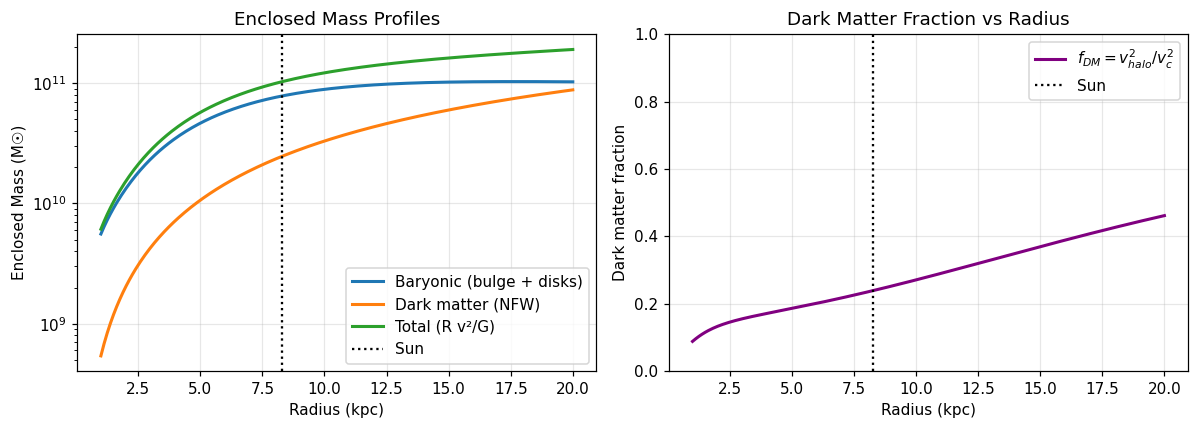

| Derived quantity | Value | Literature |
|:--|--:|:--|
| Local dark matter density $\rho_{DM}(R_0)$ | 0.20 ± 0.06 GeV/cm³ | 0.2–0.6 GeV/cm³ (Read 2014; de Salas & Widmark 2021) |
| Stellar disk mass $M_d$ | 7.1e+10 ± 1.3e+10 M☉ | ≈ 4–6 × 10¹⁰ M☉ (Bland-Hawthorn & Gerhard 2016) |
| Dark matter fraction at the Sun $f_{DM}(R_0)$ | 0.23 ± 0.07 | |

Uncertainties are statistical only and do not include the fixed bulge, gas or halo scale radius. A disk mass above the literature range paired with a low local dark matter density is the classic signature of the disk–halo degeneracy; the $R_d$ prior tightens this, but only data at larger radii can truly break it.

In [34]:
p = fits["Complex"].param
r = np.linspace(1, 20, 300)
xh = r / RS_HALO
M_halo = 4 * np.pi * p[2] * 1e7 * RS_HALO**3 * (np.log1p(xh) - xh / (1 + xh))
M_bulge = BULGE["M"] * r**2 / (r + BULGE["a"])**2
c = mw_components(r, p)
M_disks = r * (c["disk"]**2 + c["HI"]**2 + c["H2"]**2) / G
M_tot = r * v_complex(r, p)**2 / G

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].semilogy(r, M_bulge + M_disks, lw=2, label="Baryonic (bulge + disks)")
axes[0].semilogy(r, M_halo, lw=2, label="Dark matter (NFW)")
axes[0].semilogy(r, M_tot, lw=2, label="Total (R v²/G)")
axes[0].set(xlabel="Radius (kpc)", ylabel="Enclosed Mass (M☉)", title="Enclosed Mass Profiles")
axes[1].plot(r, c["halo"]**2 / v_complex(r, p)**2, color="purple", lw=2, label="$f_{DM} = v^2_{halo}/v^2_c$")
axes[1].set(xlabel="Radius (kpc)", ylabel="Dark matter fraction", title="Dark Matter Fraction vs Radius", ylim=(0, 1))
for ax in axes:
    ax.axvline(SUN["R0"], ls=":", color="k", label="Sun"); ax.legend()
plt.tight_layout(); plt.show()

# Derived quantities with uncertainties from 500 draws of the fit covariance
rng = np.random.default_rng(7)
draws = np.maximum(rng.multivariate_normal(p, fits["Complex"].cov, 500), 1e-6)
x0 = SUN["R0"] / RS_HALO
rho_dm = draws[:, 2] * 1e7 / (x0 * (1 + x0)**2) * 3.797e-8        # M_sun/kpc^3 -> GeV/cm^3
M_d = 2 * np.pi * draws[:, 0] * 1e8 * draws[:, 1]**2
f_dm = np.array([mw_components(SUN["R0"], q)["halo"]**2 / v_complex(SUN["R0"], q)**2 for q in draws])
display(Markdown(f"""| Derived quantity | Value | Literature |
|:--|--:|:--|
| Local dark matter density $\\rho_{{DM}}(R_0)$ | {np.median(rho_dm):.2f} ± {rho_dm.std():.2f} GeV/cm³ | 0.2–0.6 GeV/cm³ (Read 2014; de Salas & Widmark 2021) |
| Stellar disk mass $M_d$ | {np.median(M_d):.1e} ± {M_d.std():.1e} M☉ | ≈ 4–6 × 10¹⁰ M☉ (Bland-Hawthorn & Gerhard 2016) |
| Dark matter fraction at the Sun $f_{{DM}}(R_0)$ | {np.median(f_dm):.2f} ± {f_dm.std():.2f} | |

Uncertainties are statistical only and do not include the fixed bulge, gas or halo scale radius. A disk mass above the literature range paired with a low local dark matter density is the classic signature of the disk–halo degeneracy; the $R_d$ prior tightens this, but only data at larger radii can truly break it."""))

# Where This Could Go Next

It is not enough to stop at a single fit. The most natural next step is to replace $1/\varpi$ with the probabilistic distances of Coryn Bailer-Jones and collaborators (Bailer-Jones et al. 2021), which would let us relax the $5\sigma$ parallax cut and push the curve toward 20 kpc and beyond. After that, correcting for asymmetric drift with the Jeans equation (as Eilers et al. 2019 did) would turn our stellar $V_\phi$ into a true circular speed, and adding fainter stars from the Gaia DR3 kinematics catalogues would populate the inner galaxy where the bulge and bar live. Perhaps most exciting, *Gaia* DR4 is expected to roughly double the time baseline of the mission, which should shrink the proper-motion uncertainties several-fold. Let's stay tuned, this is a notebook that can simply be re-run the day DR4 lands in the archive, and we believe that the rotation curve of our own galaxy will only come into sharper focus from here.

# References

Bailer-Jones, C. A. L. (2015). Estimating Distances from Parallaxes. *PASP*, 127, 994. [doi:10.1086/683116](https://doi.org/10.1086/683116)

Bailer-Jones, C. A. L., Rybizki, J., Fouesneau, M., Demleitner, M., & Andrae, R. (2021). Estimating Distances from Parallaxes. V. *AJ*, 161, 147. [doi:10.3847/1538-3881/abd806](https://doi.org/10.3847/1538-3881/abd806)

Bennett, M., & Bovy, J. (2019). Vertical waves in the solar neighbourhood in Gaia DR2. *MNRAS*, 482, 1417. [doi:10.1093/mnras/sty2813](https://doi.org/10.1093/mnras/sty2813)

Binney, J., & Merrifield, M. (1998). *Galactic Astronomy*. Princeton University Press.

Binney, J., & Tremaine, S. (2008). *Galactic Dynamics* (2nd ed.). Princeton University Press.

Bland-Hawthorn, J., & Gerhard, O. (2016). The Galaxy in Context. *ARA&A*, 54, 529. [doi:10.1146/annurev-astro-081915-023441](https://doi.org/10.1146/annurev-astro-081915-023441)

de Salas, P. F., & Widmark, A. (2021). Dark matter local density determination. *Rep. Prog. Phys.*, 84, 104901. [doi:10.1088/1361-6633/ac24e7](https://doi.org/10.1088/1361-6633/ac24e7)

Deason, A. J., Fattahi, A., Belokurov, V., Evans, N. W., Grand, R. J. J., Marinacci, F., & Pakmor, R. (2019). The local high-velocity tail and the Galactic escape speed. *MNRAS*, 485, 3514. [doi:10.1093/mnras/stz623](https://doi.org/10.1093/mnras/stz623)

Eilers, A.-C., Hogg, D. W., Rix, H.-W., & Ness, M. K. (2019). The Circular Velocity Curve of the Milky Way from 5 to 25 kpc. *ApJ*, 871, 120. [doi:10.3847/1538-4357/aaf648](https://doi.org/10.3847/1538-4357/aaf648)

ESA (1997). *The Hipparcos and Tycho Catalogues*, ESA SP-1200, Vol. 1, §1.5.3.

Freeman, K. C. (1970). On the Disks of Spiral and S0 Galaxies. *ApJ*, 160, 811. [doi:10.1086/150474](https://doi.org/10.1086/150474)

Gaia Collaboration, Prusti, T., et al. (2016). The Gaia mission. *A&A*, 595, A1. [doi:10.1051/0004-6361/201629272](https://doi.org/10.1051/0004-6361/201629272)

Gaia Collaboration, Brown, A. G. A., et al. (2018). Gaia Data Release 2: Summary of the contents and survey properties. *A&A*, 616, A1. [doi:10.1051/0004-6361/201833051](https://doi.org/10.1051/0004-6361/201833051)

Gaia Collaboration, Vallenari, A., et al. (2023). Gaia Data Release 3: Summary of the content and survey properties. *A&A*, 674, A1. [doi:10.1051/0004-6361/202243940](https://doi.org/10.1051/0004-6361/202243940)

GRAVITY Collaboration, Abuter, R., et al. (2022). Mass distribution in the Galactic Center based on interferometric astrometry of multiple stellar orbits. *A&A*, 657, L12. [doi:10.1051/0004-6361/202142465](https://doi.org/10.1051/0004-6361/202142465)

Hernquist, L. (1990). An Analytical Model for Spherical Galaxies and Bulges. *ApJ*, 356, 359. [doi:10.1086/168845](https://doi.org/10.1086/168845)

Kass, R. E., & Raftery, A. E. (1995). Bayes Factors. *JASA*, 90, 773. [doi:10.1080/01621459.1995.10476572](https://doi.org/10.1080/01621459.1995.10476572)

Katz, D., et al. (2023). Gaia Data Release 3: Properties and validation of the radial velocities. *A&A*, 674, A5. [doi:10.1051/0004-6361/202244220](https://doi.org/10.1051/0004-6361/202244220)

Lindegren, L., et al. (2018). Gaia Data Release 2: The astrometric solution. *A&A*, 616, A2. [doi:10.1051/0004-6361/201832727](https://doi.org/10.1051/0004-6361/201832727)

Lindegren, L., et al. (2021). Gaia Early Data Release 3: Parallax bias versus magnitude, colour, and position. *A&A*, 649, A4. [doi:10.1051/0004-6361/202039653](https://doi.org/10.1051/0004-6361/202039653)

McMillan, P. J. (2017). The mass distribution and gravitational potential of the Milky Way. *MNRAS*, 465, 76. [doi:10.1093/mnras/stw2759](https://doi.org/10.1093/mnras/stw2759)

Navarro, J. F., Frenk, C. S., & White, S. D. M. (1996). The Structure of Cold Dark Matter Halos. *ApJ*, 462, 563. [doi:10.1086/177173](https://doi.org/10.1086/177173)

Read, J. I. (2014). The local dark matter density. *J. Phys. G*, 41, 063101. [doi:10.1088/0954-3899/41/6/063101](https://doi.org/10.1088/0954-3899/41/6/063101)

Reid, M. J., & Brunthaler, A. (2020). The Proper Motion of Sagittarius A*. III. *ApJ*, 892, 39. [doi:10.3847/1538-4357/ab76cd](https://doi.org/10.3847/1538-4357/ab76cd)

Schönrich, R., Binney, J., & Dehnen, W. (2010). Local kinematics and the local standard of rest. *MNRAS*, 403, 1829. [doi:10.1111/j.1365-2966.2010.16253.x](https://doi.org/10.1111/j.1365-2966.2010.16253.x)

Ueshima, K. (2010). *Study of pulse shape discrimination and low background techniques for liquid xenon dark matter detectors* (PhD thesis, University of Tokyo). [PDF](https://www-sk.icrr.u-tokyo.ac.jp/xmass/publist/ueshima_PhD.pdf) — the source of the original five-component decomposition.

*This work has made use of data from the European Space Agency (ESA) mission Gaia (https://www.cosmos.esa.int/gaia), processed by the Gaia Data Processing and Analysis Consortium (DPAC, https://www.cosmos.esa.int/web/gaia/dpac/consortium). Funding for the DPAC has been provided by national institutions, in particular the institutions participating in the Gaia Multilateral Agreement.*

# Saving the Results

The cell below gathers every key number from this run — the query log, sample sizes, overlap audit, binned curves, fitted parameters, model-comparison tables and derived dark matter quantities — into `results_summary.json` next to this notebook. Together with this notebook saved *with its outputs*, it is everything needed to review the analysis without re-running the queries.

In [35]:
summary = dict(
    run_at=datetime.datetime.now().isoformat(timespec="seconds"),
    data_source=data_source,
    query_log=query_log,
    dr2_query_used=queries["test"],
    settings=dict(N_ROWS=N_ROWS, SUBSET=SUBSET, BIN_WIDTH=BIN_WIDTH, SIGMA_SYS=SIGMA_SYS, USE_RD_PRIOR=USE_RD_PRIOR),
    sun={k: float(v) for k, v in SUN.items()},
    counts=dict(raw_train=len(raw_train), raw_test=len(raw_test), overlap=ov,
                train_after_cuts=len(train_all), test_after_cuts=len(test_all),
                train_bins=len(bins_train), test_bins=len(bins_test)),
    R_quantiles_kpc=dict(train=[float(train_all.R.quantile(q)) for q in (0.01, 0.5, 0.99)],
                         test=[float(test_all.R.quantile(q)) for q in (0.01, 0.5, 0.99)] if len(test_all) else None),
    median_vphi_error=dict(train=float(train_all.vphi_error.median()),
                           test=float(test_all.vphi_error.median()) if len(test_all) else None),
    fits={m: dict(param=ft.param.tolist(), err=ft.err.tolist(), converged=bool(ft.converged)) for m, ft in fits.items()},
    refit_on_test=({m: dict(param=ft.param.tolist(), err=ft.err.tolist()) for m, ft in refit.items()}
                   if "refit" in globals() else None),
    model_table=fit_table.round(3).to_dict(orient="records"),
    test_table=test_table.round(3).to_dict(orient="records"),
    derived=dict(rho_dm_GeV_cm3=[float(np.median(rho_dm)), float(rho_dm.std())],
                 disk_mass_Msun=[float(np.median(M_d)), float(M_d.std())],
                 f_dm_R0=[float(np.median(f_dm)), float(f_dm.std())]),
    bins_train=bins_train.round(3).to_dict(orient="list"),
    bins_test=bins_test.round(3).to_dict(orient="list"),
)
Path("results_summary.json").write_text(json.dumps(summary, indent=2, default=int))
print("Wrote results_summary.json")

Wrote results_summary.json
